# PipelineE K=3 manuscript figure notebook

This notebook generates a **manuscript-oriented figure set** for the selected **PipelineE K=3 fusion HMM** using the saved outputs and the Schaefer-200 / 7-network atlas setup already used earlier in preprocessing.

## Figure set
1. **State dynamics**
   - subject-level fractional occupancy (FO)
   - expected dwell per state
   - transition matrix heatmap
   - optional run-level stacked FO bars
   - per-run state-activation raster from segmented gamma files
   - example Gamma / Viterbi trajectory if available

2. **Network physiology**
   - state-wise network block heatmaps
   - difference heatmaps versus the dominant/reference state

3. **Ranked contrasts**
   - top network-pair changes
   - top parcel-level changes

4. **Parcel brain maps**
   - parcel-wise nodal mean connectivity mapped back to brain space
   - difference maps versus the reference state
   - volume/surface plotting with graceful fallback

5. **Optional transition visualization**
   - directed transition graph
   - Sankey diagram

6. **State-by-state glossary**
   - compact manuscript-ready biological summaries for S1, S2, S3


In [1]:
from pathlib import Path
import json, math, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
warnings.filterwarnings("ignore", category=RuntimeWarning)

try:
    import nibabel as nib
except Exception:
    nib = None

try:
    from nilearn import plotting
except Exception:
    plotting = None

try:
    import networkx as nx
except Exception:
    nx = None

try:
    import plotly.graph_objects as go
except Exception:
    go = None


In [2]:
# =========================
# User config
# =========================
RESULT_ROOT = Path(
    "/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/"
    "PipelineE_final_K03_intermediate_nolags_minlen15"
)
FINAL_DIR = RESULT_ROOT / "final"

TEMPLATEFLOW_HOME = Path("/mnt/c/EEGFMRI_PIPELINE/templateflow")
TF_TPL_DIR = TEMPLATEFLOW_HOME / "tpl-MNI152NLin2009cAsym"
DEFAULT_SCHAEFER_TSV = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv"
DEFAULT_SCHAEFER_NII = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.nii.gz"
DEFAULT_BRAINSTORM_TXT = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.txt"

PARCEL_LABELS_FILE = None
PREPROC_PARAMS_FILE = None
REFERENCE_STATE = None  # 1-based (e.g. 2 for S2) or None
TR_SEC = 2.1
TOP_N_NETWORK = 10
TOP_N_PARCEL = 15
NETWORK_ORDER = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
USE_ABS_FOR_BLOCK_MEANS = False


GAMMA_DIR = RESULT_ROOT / "gamma"
VITERBI_DIR = RESULT_ROOT / "viterbi"
GAMMA_ACTIVE_THRESH = 0.30
EXAMPLE_RUN_NAME = None   # e.g. "sub-03_ses-01"
RASTER_RUN_ORDER = None   # list of run names, or None to use run_metrics order
SHOW_RUN_LABELS = True

OUT_DIR = RESULT_ROOT / "manuscript_figures"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
for _p in (OUT_DIR, FIG_DIR, TAB_DIR):
    _p.mkdir(parents=True, exist_ok=True)

print("RESULT_ROOT:", RESULT_ROOT)
print("FINAL_DIR  :", FINAL_DIR)
print("OUT_DIR    :", OUT_DIR)
print("FIG_DIR    :", FIG_DIR)
print("TAB_DIR    :", TAB_DIR)


RESULT_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15
FINAL_DIR  : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final
OUT_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures
FIG_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures/figures
TAB_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures/tables


In [3]:
# =========================
# Helpers
# =========================

def resolve_existing(*candidates):
    for c in candidates:
        if c is None:
            continue
        p = Path(c)
        if p.exists():
            return p
    return None

def infer_result_file(name):
    p = resolve_existing(RESULT_ROOT / name, FINAL_DIR / name, Path(name))
    if p is None:
        raise FileNotFoundError(f"Could not find required file: {name}")
    return p

def load_json(path):
    return json.loads(Path(path).read_text())

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()

def infer_n_from_ut_length(m):
    n = int((1 + math.sqrt(1 + 8*m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Upper-triangle length {m} does not match any n x n matrix.")
    return n

def ut_to_square(vec, fill_diag=1.0):
    vec = np.asarray(vec)
    n = infer_n_from_ut_length(vec.size)
    M = np.zeros((n, n), dtype=np.float32)
    iu = np.triu_indices(n, 1)
    M[iu] = vec
    M[(iu[1], iu[0])] = vec
    np.fill_diagonal(M, fill_diag)
    return M

def extract_network(label):
    parts = str(label).split("_")
    if len(parts) < 4:
        return "Unknown"
    return parts[2]

def extract_hemi(label):
    parts = str(label).split("_")
    if len(parts) < 3:
        return "?"
    return "L" if parts[1] == "LH" else ("R" if parts[1] == "RH" else "?")

def load_schaefer_labels():
    tsv = resolve_existing(PARCEL_LABELS_FILE, DEFAULT_SCHAEFER_TSV)
    if tsv is not None:
        df = pd.read_csv(tsv, sep="	")
        cand_name = [c for c in df.columns if c.lower() in ("name", "label", "labels")]
        if len(cand_name) == 0:
            raise ValueError(f"Could not find parcel label column in {tsv}")
        name_col = cand_name[0]
        labels = df[name_col].astype(str).tolist()
        out = pd.DataFrame({"index": np.arange(len(labels)), "label": labels})
        out["label_short"] = out["label"].str.replace("^7Networks_", "", regex=True)
        out["network"] = out["label"].map(extract_network)
        out["hemi"] = out["label"].map(extract_hemi)
        return out, tsv
    txt = resolve_existing(PARCEL_LABELS_FILE, DEFAULT_BRAINSTORM_TXT)
    if txt is not None:
        raw = Path(txt).read_text(encoding="utf-8", errors="ignore").splitlines()
        labels = [line.strip() for line in raw if line.strip() and "7Networks_" in line]
        labels = labels[:200]
        out = pd.DataFrame({"index": np.arange(len(labels)), "label": labels})
        out["label_short"] = out["label"].str.replace("^7Networks_", "", regex=True)
        out["network"] = out["label"].map(extract_network)
        out["hemi"] = out["label"].map(extract_hemi)
        return out, txt
    labels = [f"parcel_{i+1:03d}" for i in range(200)]
    out = pd.DataFrame({"index": np.arange(len(labels)), "label": labels, "label_short": labels, "network": "Unknown", "hemi": "?"})
    return out, None

def network_boundaries(labels_df, network_order):
    sizes = [(labels_df["network"] == net).sum() for net in network_order]
    bounds = np.cumsum(sizes)
    return sizes, bounds

def reorder_by_network(labels_df, network_order):
    sort_key = pd.Categorical(labels_df["network"], categories=network_order, ordered=True)
    ordered = labels_df.assign(_network_order=sort_key).sort_values(["_network_order", "hemi", "label_short"]).reset_index(drop=True)
    idx = ordered["index"].to_numpy()
    return ordered.drop(columns="_network_order"), idx

def compute_network_blocks(mat, labels_df, network_order, use_abs=False):
    out = pd.DataFrame(index=network_order, columns=network_order, dtype=float)
    arr = np.abs(mat) if use_abs else mat
    for a in network_order:
        ia = labels_df.index[labels_df["network"] == a].to_numpy()
        for b in network_order:
            ib = labels_df.index[labels_df["network"] == b].to_numpy()
            if len(ia) == 0 or len(ib) == 0:
                out.loc[a, b] = np.nan
                continue
            block = arr[np.ix_(ia, ib)]
            if a == b:
                mask = ~np.eye(len(ia), dtype=bool)
                vals = block[mask]
            else:
                vals = block.ravel()
            out.loc[a, b] = np.nanmean(vals)
    return out

def compute_nodal_mean_r(mat):
    tmp = mat.copy().astype(float)
    np.fill_diagonal(tmp, np.nan)
    return np.nanmean(tmp, axis=1)

def maybe_load_example_state_series():
    candidates = []
    candidates += list(RESULT_ROOT.glob("*Gamma*perTR*.npy"))
    candidates += list(FINAL_DIR.glob("*Gamma*perTR*.npy"))
    candidates += list(RESULT_ROOT.glob("*Viterbi*perTR*.npy"))
    candidates += list(FINAL_DIR.glob("*Viterbi*perTR*.npy"))
    return sorted(set(candidates))



def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(s))]

def normalize_viterbi(v, K=None):
    v = np.asarray(v)
    if v.ndim > 1:
        if v.shape[1] == 1:
            v = v[:, 0]
        else:
            v = np.argmax(v, axis=1)
    v = v.astype(float)
    good = np.isfinite(v)
    if not np.any(good):
        return v.astype(int)
    vals = np.unique(v[good]).astype(int)
    if K is not None:
        if vals.min() == 1 and vals.max() <= K:
            v = v - 1
        elif vals.min() == 0 and vals.max() <= K - 1:
            pass
        elif vals.min() == 1 and vals.max() == K + 1:
            v = v - 1
    return v.astype(int)

def list_segment_files(run_dir, kind):
    run_dir = Path(run_dir)
    files = sorted(run_dir.glob(f"{kind}_seg*.npy"), key=lambda p: natural_sort_key(p.name))
    return files


def load_segment_series(run_dir, kind, K=None):
    files = list_segment_files(run_dir, kind)
    if len(files) == 0:
        return None, []
    arrs = [np.load(f) for f in files]
    if kind.lower() == 'gamma':
        arrs = [a if a.ndim == 2 else np.atleast_2d(a) for a in arrs]
        arr = np.concatenate(arrs, axis=0)
        if K is not None and arr.shape[1] != K:
            raise ValueError(f"Gamma for {run_dir.name} has {arr.shape[1]} states, expected {K}.")
        return arr, files
    elif kind.lower() == 'viterbi':
        arrs = [normalize_viterbi(a, K=K) for a in arrs]
        arr = np.concatenate(arrs, axis=0)
        return arr, files
    else:
        arr = np.concatenate(arrs, axis=0)
        return arr, files


def discover_segment_runs(gamma_dir=None, viterbi_dir=None):
    gamma_dir = Path(gamma_dir) if gamma_dir is not None else None
    viterbi_dir = Path(viterbi_dir) if viterbi_dir is not None else None
    runs = {}
    for base, kind in [(gamma_dir, 'gamma'), (viterbi_dir, 'viterbi')]:
        if base is None or not base.exists():
            continue
        for run_dir in sorted(base.glob('sub-*'), key=lambda p: natural_sort_key(p.name)):
            if run_dir.is_dir():
                runs.setdefault(run_dir.name, {})[kind] = run_dir
    return runs


def build_run_state_series(run_names, gamma_dir=None, viterbi_dir=None, K=None):
    discovered = discover_segment_runs(gamma_dir=gamma_dir, viterbi_dir=viterbi_dir)
    out = []
    for run_name in run_names:
        info = {'run': run_name, 'gamma': None, 'viterbi': None, 'n_gamma': 0, 'n_viterbi': 0, 'T': None}
        run_entry = discovered.get(run_name, {})
        if 'gamma' in run_entry:
            gamma, gfiles = load_segment_series(run_entry['gamma'], 'gamma', K=K)
            info['gamma'] = gamma
            info['gamma_files'] = gfiles
            info['n_gamma'] = len(gfiles)
            info['T'] = gamma.shape[0]
        if 'viterbi' in run_entry:
            vit, vfiles = load_segment_series(run_entry['viterbi'], 'viterbi', K=K)
            info['viterbi'] = vit
            info['viterbi_files'] = vfiles
            info['n_viterbi'] = len(vfiles)
            if info['T'] is None:
                info['T'] = vit.shape[0]
        out.append(info)
    return out

def parcel_values_to_img(parcel_values, atlas_nii):
    if nib is None:
        raise ImportError("nibabel is not installed.")
    atlas_img = nib.load(str(atlas_nii))
    atlas_data = atlas_img.get_fdata()
    out = np.zeros(atlas_data.shape, dtype=np.float32)
    for i, val in enumerate(parcel_values, start=1):
        out[atlas_data == i] = float(val)
    return nib.Nifti1Image(out, affine=atlas_img.affine, header=atlas_img.header)


from matplotlib.colors import Normalize

def contrast_text_for_colormap(val, vmin, vmax, cmap="viridis"):
    """
    Choose annotation color based on the background color produced by the colormap.
    Very dark background  -> yellow
    Moderately dark       -> white
    Bright background     -> black
    """
    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(vmin=vmin, vmax=vmax)
    r, g, b, _ = cmap_obj(norm(val))

    # perceived luminance
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b

    if luminance < 0.28:
        return "#FDE725"   # bright yellow
    elif luminance < 0.55:
        return "white"
    else:
        return "black"


In [4]:
# =========================
# Resolve files and load outputs
# =========================
required = {
    "qc_summary": infer_result_file("qc_summary.json"),
    "subject_metrics": infer_result_file("subject_metrics.tsv"),
    "run_metrics": infer_result_file("run_metrics.tsv"),
    "trans_prob": infer_result_file("trans_prob.npy"),
    "state_signature": infer_result_file("state_signature_ut_boldcorr.npy"),
}
optional = {
    "covs_pca": resolve_existing(FINAL_DIR / "covs_pca.npy", RESULT_ROOT / "covs_pca.npy"),
    "refit_results": resolve_existing(FINAL_DIR / "refit_results.json", RESULT_ROOT / "refit_results.json"),
    "dwell_from_A": resolve_existing(RESULT_ROOT / "dwell_from_A.tsv"),
    "state_summary": resolve_existing(RESULT_ROOT / "state_summary_table.tsv"),
    "atlas_nii": resolve_existing(DEFAULT_SCHAEFER_NII),
    "gamma_dir": resolve_existing(GAMMA_DIR, RESULT_ROOT / "gamma", FINAL_DIR / "gamma"),
    "viterbi_dir": resolve_existing(VITERBI_DIR, RESULT_ROOT / "viterbi", FINAL_DIR / "viterbi"),
}
print("Resolved files:")
for k, v in required.items():
    print(f"  {k:18s} -> {v}")
for k, v in optional.items():
    print(f"  {k:18s} -> {v}")

qc = load_json(required["qc_summary"])
subject_metrics = pd.read_csv(required["subject_metrics"], sep="	")
run_metrics = pd.read_csv(required["run_metrics"], sep="	")
A = np.load(required["trans_prob"])
sig_ut = np.load(required["state_signature"])
covs_pca = np.load(optional["covs_pca"]) if optional["covs_pca"] is not None else None
refit_results = load_json(optional["refit_results"]) if optional["refit_results"] else None
dwell_tbl = pd.read_csv(optional["dwell_from_A"], sep="	") if optional["dwell_from_A"] else None
state_summary_file = pd.read_csv(optional["state_summary"], sep="	") if optional["state_summary"] else None
labels_df_raw, label_source = load_schaefer_labels()
print("\nMain dimensions")
print("A shape               :", A.shape)
print("state_signature shape :", sig_ut.shape)
if covs_pca is not None:
    print("covs_pca shape        :", covs_pca.shape)
print("label source          :", label_source)
print("n parcels             :", len(labels_df_raw))


Resolved files:
  qc_summary         -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/qc_summary.json
  subject_metrics    -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/subject_metrics.tsv
  run_metrics        -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/run_metrics.tsv
  trans_prob         -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/trans_prob.npy
  state_signature    -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/state_signature_ut_boldcorr.npy
  covs_pca           -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen

In [5]:
# =========================
# Reconstruct state matrices and state-level summaries
# =========================
K = sig_ut.shape[0]
parcel_mats = np.stack([ut_to_square(sig_ut[k], fill_diag=1.0) for k in range(K)], axis=0)

if refit_results is not None and len(refit_results) > 0:
    refit_df = pd.DataFrame(refit_results).sort_values("fe").reset_index(drop=True)
    final_fo = np.asarray(refit_df.loc[0, "fo"], dtype=float)
else:
    if state_summary_file is None:
        raise ValueError("Need either refit_results.json or state_summary_table.tsv to recover final FO.")
    final_fo = state_summary_file.sort_values("state")["final_FO"].to_numpy()

dominant_state_idx = int(np.argmax(final_fo))
ref_idx = dominant_state_idx if REFERENCE_STATE is None else int(REFERENCE_STATE) - 1
ordered_labels_df, order_idx = reorder_by_network(labels_df_raw, NETWORK_ORDER)
parcel_mats_ord = parcel_mats[:, order_idx][:, :, order_idx]
nodal_mean = np.stack([compute_nodal_mean_r(parcel_mats[k]) for k in range(K)], axis=0)
nodal_mean_ord = nodal_mean[:, order_idx]
block_mats = [compute_network_blocks(parcel_mats_ord[k], ordered_labels_df, NETWORK_ORDER, use_abs=USE_ABS_FOR_BLOCK_MEANS) for k in range(K)]
state_rows = []
for k in range(K):
    row = {
        "state": f"S{k+1}",
        "is_dominant": int(k == dominant_state_idx),
        "is_reference": int(k == ref_idx),
        "final_FO": float(final_fo[k]),
        "self_transition_Akk": float(A[k, k]),
        "expected_dwell_TR": float(1.0 / (1.0 - A[k, k])),
        "expected_dwell_sec": float(TR_SEC / (1.0 - A[k, k])),
    }
    pairs = []
    for a in NETWORK_ORDER:
        for b in NETWORK_ORDER:
            pairs.append((f"{a} -- {b}", float(block_mats[k].loc[a, b])))
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)
    for j, (p, v) in enumerate(pairs[:5], start=1):
        row[f"top_block_{j}"] = p
        row[f"top_block_{j}_value"] = v
    state_rows.append(row)
state_summary = pd.DataFrame(state_rows)
state_summary.to_csv(TAB_DIR / "state_summary_table.tsv", sep="	", index=False)
print("Final FO vector:", np.round(final_fo, 6))
print("Dominant state :", f"S{dominant_state_idx+1}")
print("Reference state:", f"S{ref_idx+1}")
display(state_summary)


Final FO vector: [0.089823 0.807597 0.10258 ]
Dominant state : S2
Reference state: S2


,state,is_dominant,is_reference,final_FO,self_transition_Akk,expected_dwell_TR,expected_dwell_sec,top_block_1,top_block_1_value,top_block_2,top_block_2_value,top_block_3,top_block_3_value,top_block_4,top_block_4_value,top_block_5,top_block_5_value
0,S1,0,0,0.089823,0.183623,1.224924,2.572340,Vis -- Vis,0.348612,SomMot -- SomMot,0.246697,DorsAttn -- DorsAttn,0.239659,SalVentAttn -- SalVentAttn,0.232641,Default -- Default,0.177747
1,S2,1,1,0.807597,0.839828,6.243287,13.110902,Vis -- Vis,0.408409,SomMot -- SomMot,0.358683,SalVentAttn -- SalVentAttn,0.304162,DorsAttn -- DorsAttn,0.289321,Default -- Default,0.236813
2,S3,0,0,0.102580,0.233922,1.305351,2.741236,Vis -- Vis,0.381193,SomMot -- SomMot,0.380916,Limbic -- Limbic,0.309490,SalVentAttn -- SalVentAttn,0.273389,DorsAttn -- DorsAttn,0.218707


/tmp/ipykernel_3248/2552443732.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=states, patch_artist=True)


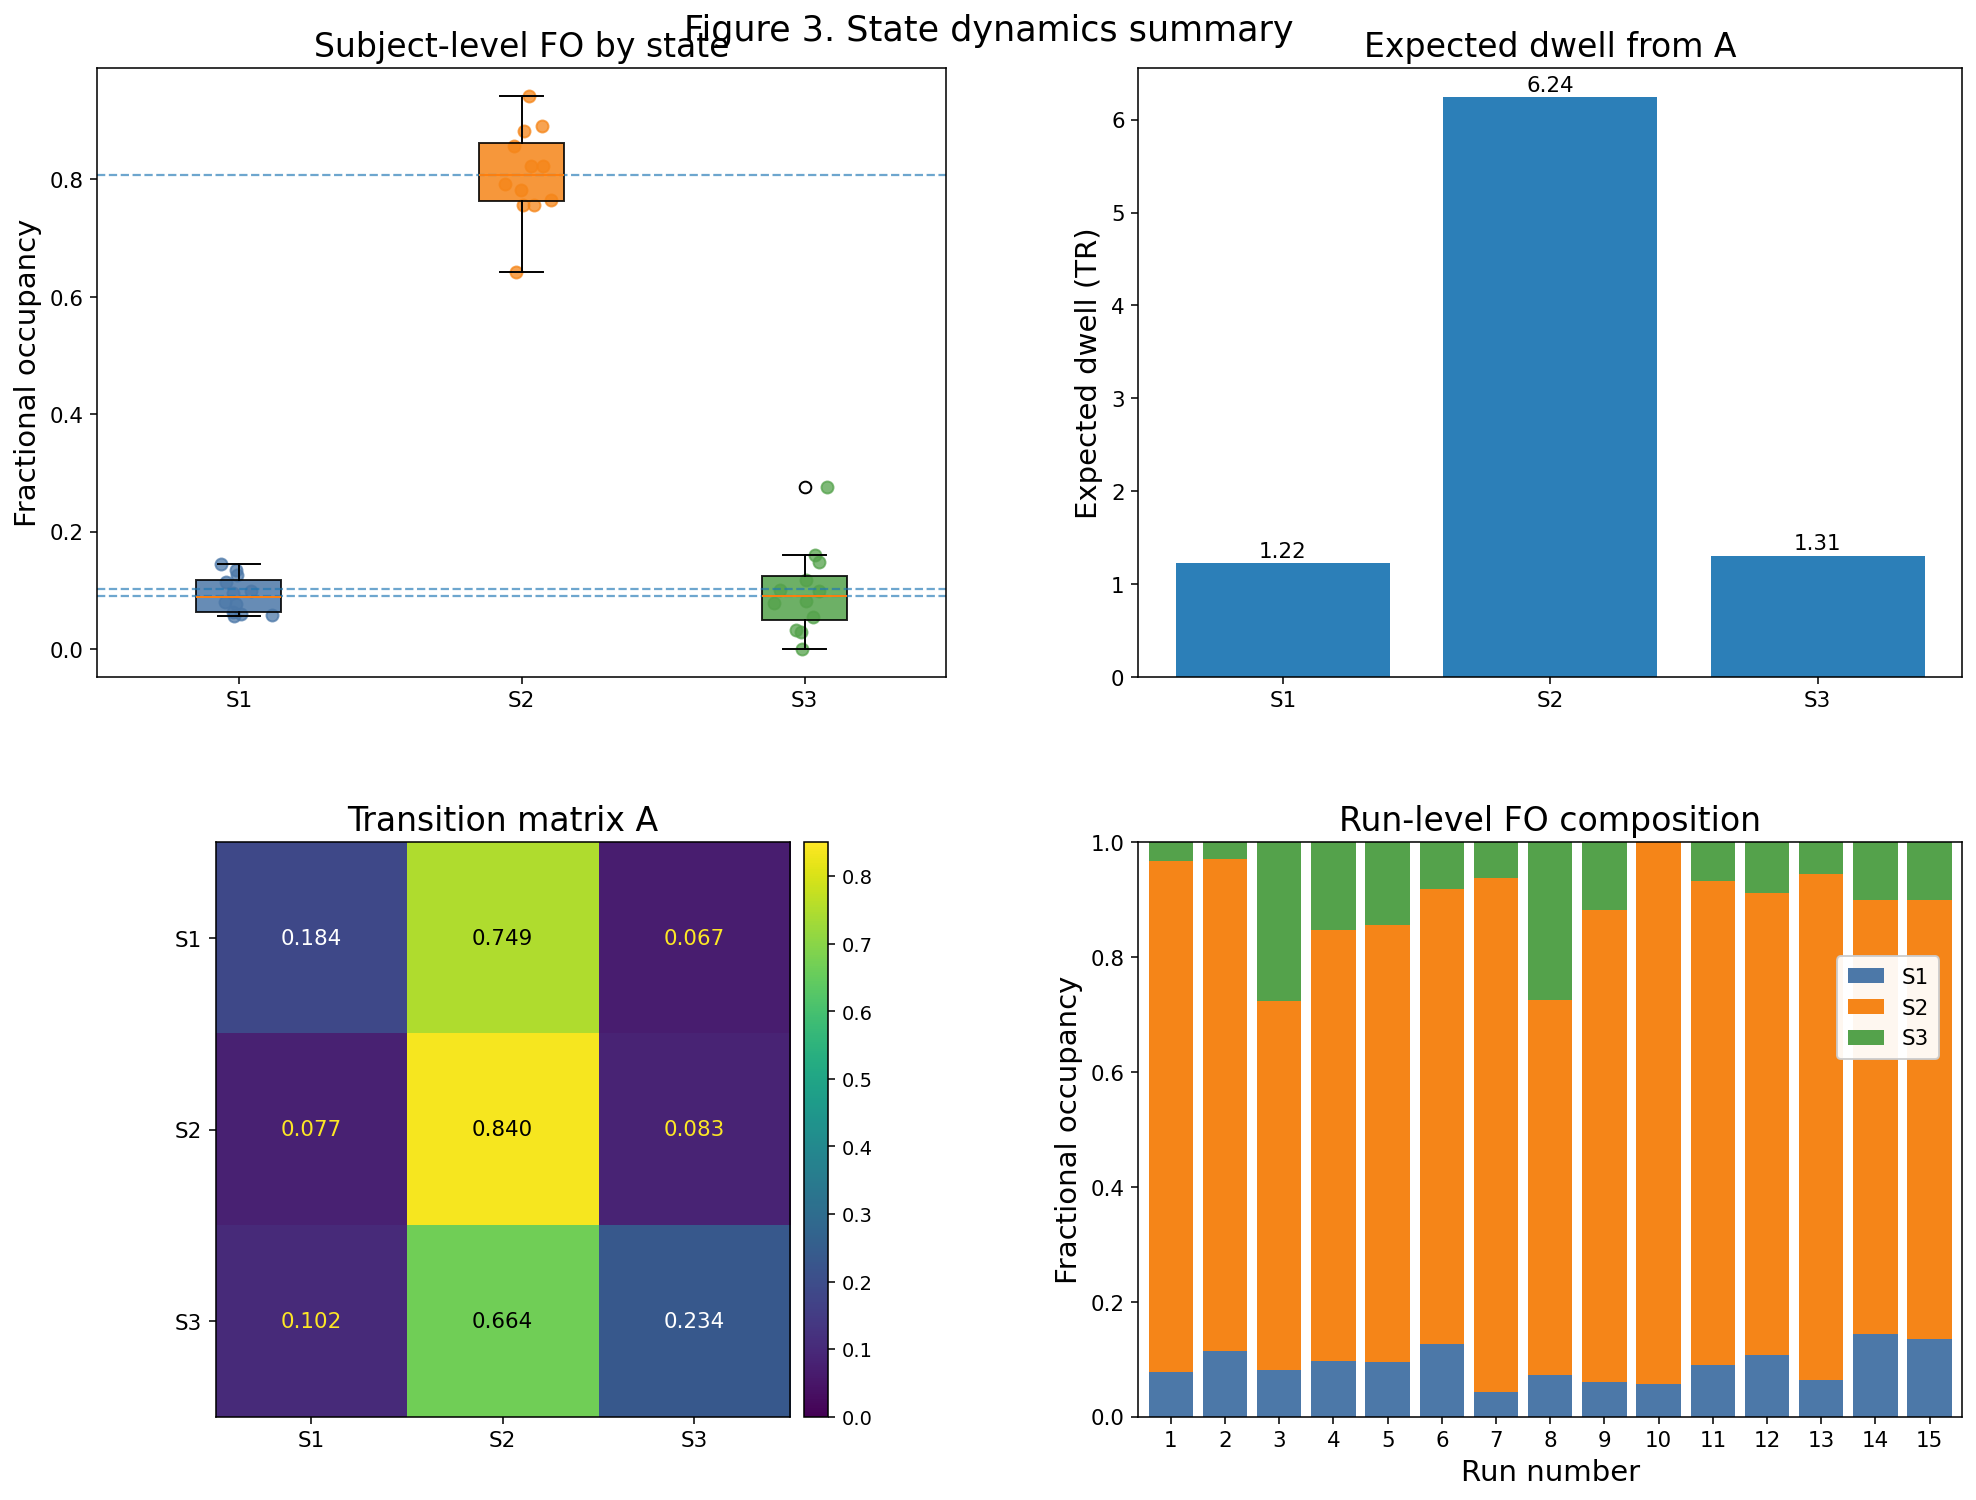

In [6]:
# =========================
# Figure 3 — state dynamics
# =========================
fo_cols = sorted(
    [c for c in subject_metrics.columns if re.fullmatch(r"FO_s\d{2}", c)]
)
fo_subj = subject_metrics[["subject"] + fo_cols].copy()
fo_long = fo_subj.melt(id_vars="subject", var_name="state_code", value_name="FO")
fo_long["state"] = fo_long["state_code"].str.extract(r"s(\d+)$").astype(int).astype(str).radd("S")

fig = plt.figure(figsize=(14.8, 11.2), constrained_layout=False)
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.06, 1.0],
    width_ratios=[1.03, 1.00]
)

states = [f"S{i+1}" for i in range(K)]
box_colors = ["#4C78A8", "#F58518", "#54A24B"]

# -------------------------
# A. Subject-level FO
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
data = [fo_long.loc[fo_long["state"] == s, "FO"].to_numpy() for s in states]

bp = ax1.boxplot(data, labels=states, patch_artist=True)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, y in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(y))
    ax1.scatter(x, y, s=38, alpha=0.75, color=box_colors[i-1])

ax1.set_ylabel("Fractional occupancy")
ax1.set_title("Subject-level FO by state")
for i in range(K):
    ax1.axhline(final_fo[i], ls="--", lw=1.15, alpha=0.65)

# -------------------------
# B. Expected dwell
# -------------------------
ax2 = fig.add_subplot(gs[0, 1])
dwell_tr = 1.0 / (1.0 - np.diag(A))
bars = ax2.bar(states, dwell_tr, color="#2C7FB8")
ax2.set_ylabel("Expected dwell (TR)")
ax2.set_title("Expected dwell from A")
for rect, val in zip(bars, dwell_tr):
    ax2.text(
        rect.get_x() + rect.get_width()/2,
        rect.get_height() + 0.02,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# -------------------------
# C. Transition matrix
# -------------------------
ax3 = fig.add_subplot(gs[1, 0])
tm_vmin = 0.0
tm_vmax = max(0.85, float(A.max()))
im = ax3.imshow(A, vmin=tm_vmin, vmax=tm_vmax, cmap="viridis")
ax3.set_xticks(range(K), states)
ax3.set_yticks(range(K), states)
ax3.set_title("Transition matrix A")

for i in range(K):
    for j in range(K):
        txt_color = contrast_text_for_colormap(A[i, j], tm_vmin, tm_vmax, cmap="viridis")
        ax3.text(
            j, i, f"{A[i, j]:.3f}",
            ha="center", va="center",
            color=txt_color,
            fontsize=11
        )

# Slightly smaller colorbar and tighter to matrix so the matrix stays visually left
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="4.2%", pad=0.10)
cb = fig.colorbar(im, cax=cax)
cb.ax.tick_params(labelsize=10)

# -------------------------
# D. Run-level FO composition
# -------------------------
ax4 = fig.add_subplot(gs[1, 1])
run_fo_cols = sorted(
    [c for c in run_metrics.columns if re.fullmatch(r"FO_s\d{2}", c)]
)

run_numbers = np.arange(1, len(run_metrics) + 1)
bottom = np.zeros(len(run_metrics))
bar_colors = ["#4C78A8", "#F58518", "#54A24B"]

for i, c in enumerate(run_fo_cols):
    vals = run_metrics[c].to_numpy()
    ax4.bar(
        run_numbers,
        vals,
        bottom=bottom,
        label=f"S{i+1}",
        color=bar_colors[i],
        width=0.82
    )
    bottom += vals

ax4.set_ylim(0, 1.0)
ax4.set_xlim(0.4, len(run_numbers) + 0.6)
ax4.set_xticks(run_numbers)
ax4.set_xticklabels(run_numbers)
ax4.set_xlabel("Run number")
ax4.set_ylabel("Fractional occupancy")
ax4.set_title("Run-level FO composition")

# Put the legend lower so it mostly overlaps orange, not green
ax4.legend(
    loc="upper right",
    bbox_to_anchor=(0.985, 0.82),
    frameon=True,
    framealpha=0.94,
    borderpad=0.5,
    handlelength=1.7
)

fig.suptitle("Figure 3. State dynamics summary", y=0.965, fontsize=18)

# Add more breathing room between panels
fig.subplots_adjust(
    left=0.07,
    right=0.97,
    bottom=0.07,
    top=0.93,
    wspace=0.23,
    hspace=0.28
)

savefig(fig, "Fig3_state_dynamics_summary.png")

,run,subject,T,has_gamma,has_viterbi,n_gamma_segments,n_viterbi_segments
0,sub-01_ses-01,sub-01,260,1,1,6,6
1,sub-02_ses-01,sub-02,270,1,1,2,2
2,sub-03_ses-01,sub-03,210,1,1,8,8
3,sub-08_ses-01,sub-08,190,1,1,5,5
4,sub-08_ses-02,sub-08,180,1,1,5,5
5,sub-09_ses-01,sub-09,220,1,1,2,2
6,sub-13_ses-01,sub-13,240,1,1,2,2
7,sub-13_ses-02,sub-13,210,1,1,7,7
8,sub-14_ses-01,sub-14,250,1,1,4,4
9,sub-16_ses-01,sub-16,200,1,1,5,5


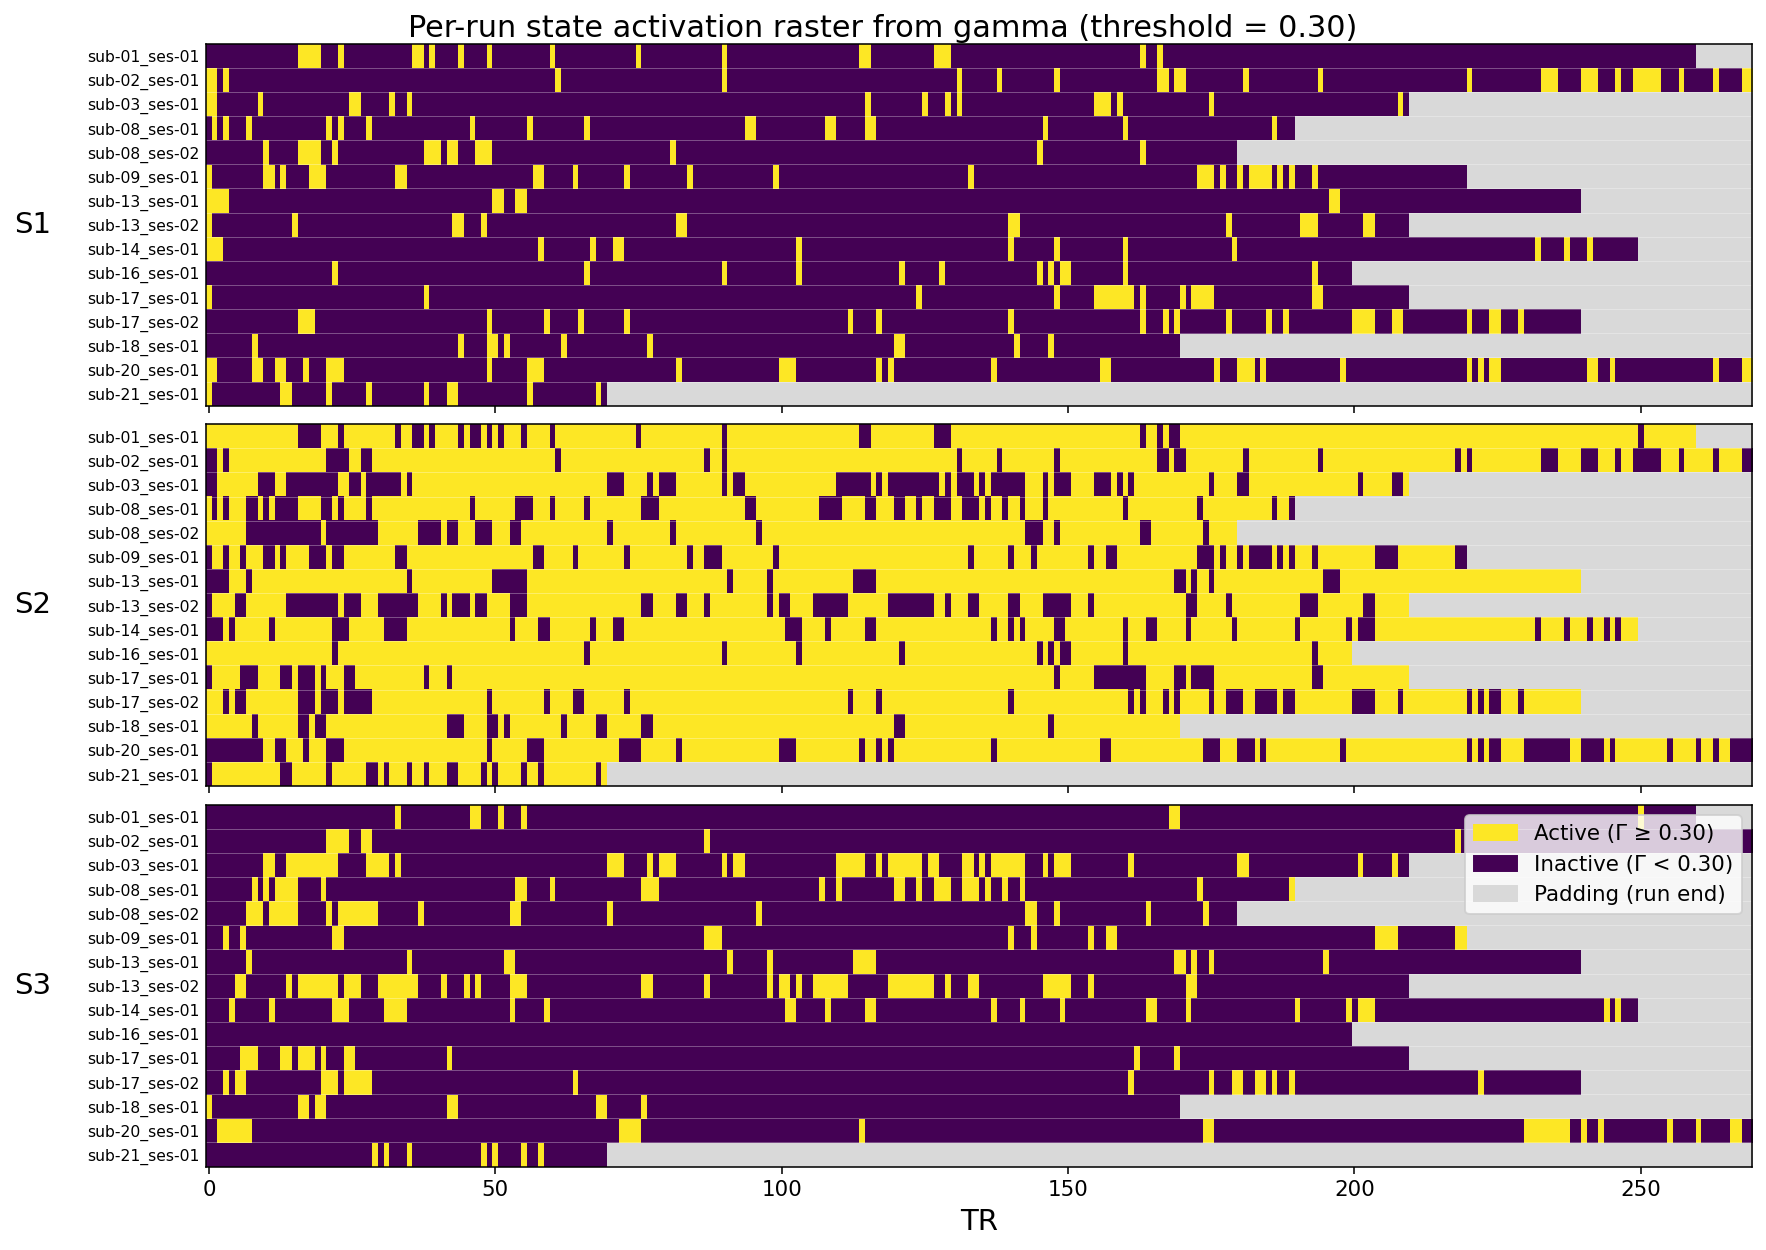

/tmp/ipykernel_3248/4153866298.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_states = plt.cm.get_cmap('viridis', K)


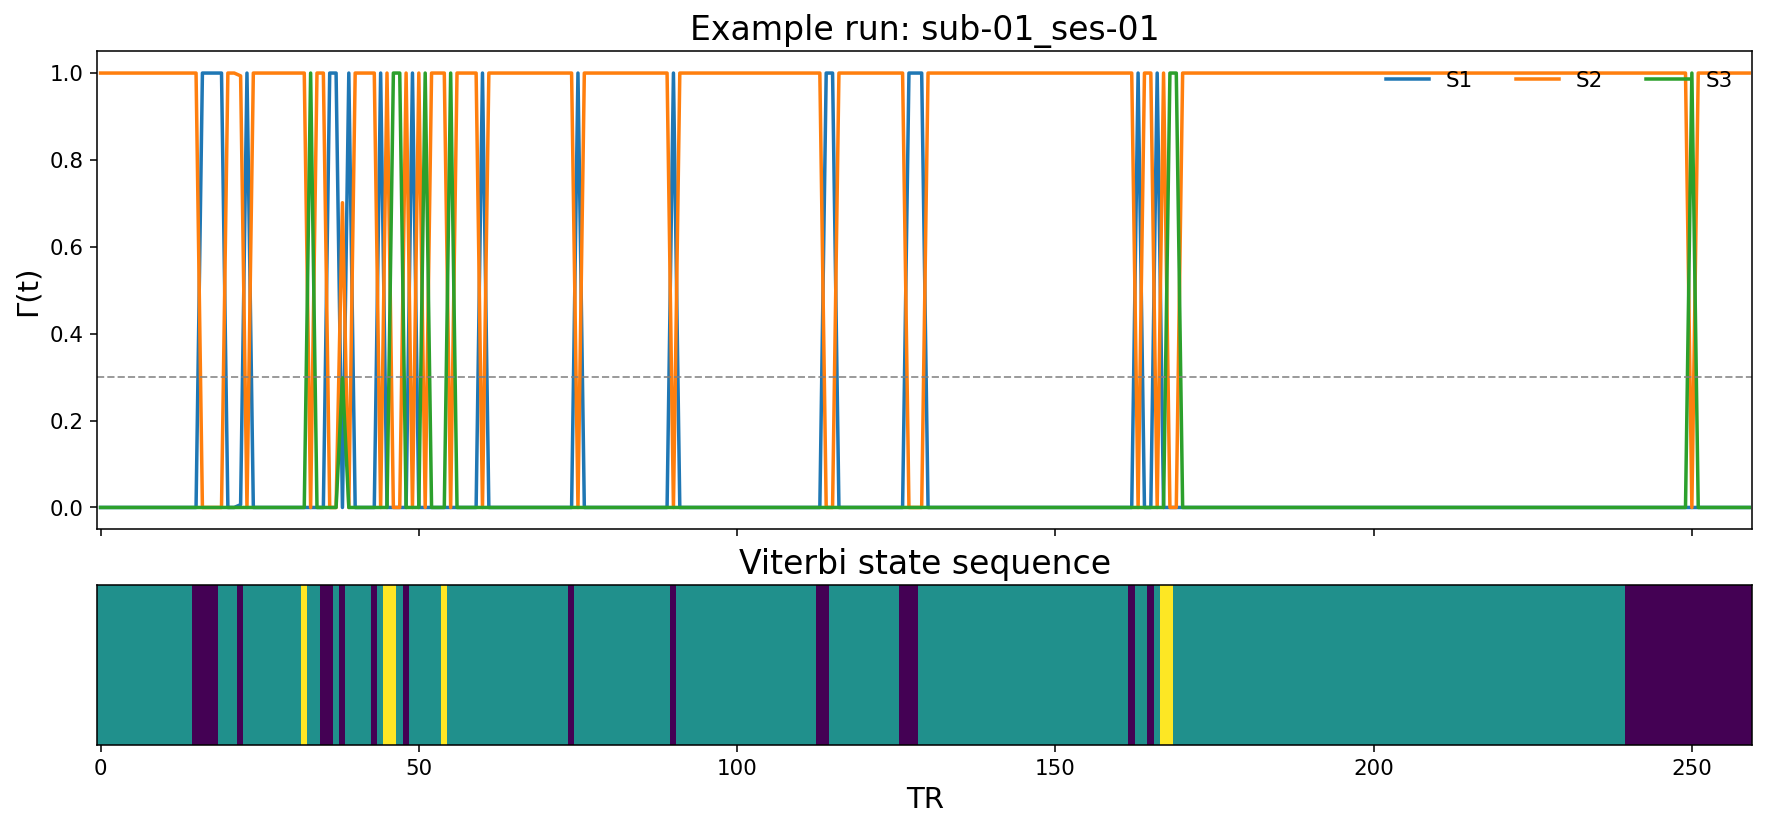

In [7]:
# Figure 1b — per-run state activation raster and example trajectory
series_runs = build_run_state_series(
    run_names=(RASTER_RUN_ORDER if RASTER_RUN_ORDER is not None else run_metrics['run'].astype(str).tolist()),
    gamma_dir=optional['gamma_dir'],
    viterbi_dir=optional['viterbi_dir'],
    K=K,
)
series_summary = pd.DataFrame([
    {
        'run': d['run'],
        'subject': d['run'].split('_')[0] if '_' in d['run'] else d['run'],
        'T': d['T'],
        'has_gamma': int(d['gamma'] is not None),
        'has_viterbi': int(d['viterbi'] is not None),
        'n_gamma_segments': d.get('n_gamma', 0),
        'n_viterbi_segments': d.get('n_viterbi', 0),
    }
    for d in series_runs
])
display(series_summary)
series_summary.to_csv(TAB_DIR / 'run_state_series_summary.tsv', sep='	', index=False)

available_gamma = [d for d in series_runs if d['gamma'] is not None]
if len(available_gamma) == 0:
    print('No segmented gamma files were found under:', optional['gamma_dir'])
else:
    max_T = max(int(d['gamma'].shape[0]) for d in available_gamma)
    raster_cmap = plt.matplotlib.colors.ListedColormap(['#d9d9d9', '#440154', '#FDE725'])
    raster_norm = plt.matplotlib.colors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], raster_cmap.N)

    fig, axes = plt.subplots(K, 1, figsize=(12.5, 2.2*K + 2.0), sharex=True, constrained_layout=True)
    if K == 1:
        axes = [axes]
    ylabels = [d['run'] if SHOW_RUN_LABELS else '' for d in available_gamma]

    for k, ax in enumerate(axes):
        raster = np.full((len(available_gamma), max_T), -1, dtype=int)
        for i, d in enumerate(available_gamma):
            active = (d['gamma'][:, k] >= GAMMA_ACTIVE_THRESH).astype(int)
            inactive = np.zeros_like(active)
            vals = np.where(active == 1, 1, 0)
            raster[i, :len(vals)] = vals
        im = ax.imshow(raster, aspect='auto', interpolation='nearest', cmap=raster_cmap, norm=raster_norm)
        ax.set_ylabel(f'S{k+1}', rotation=0, labelpad=28, va='center')
        ax.set_yticks(np.arange(len(available_gamma)))
        ax.set_yticklabels(ylabels, fontsize=8)
        ax.tick_params(axis='y', length=0)
        for i in range(1, len(available_gamma)):
            ax.axhline(i - 0.5, color='white', lw=0.35, alpha=0.45)
    axes[-1].set_xlabel('TR')
    fig.suptitle(f'Per-run state activation raster from gamma (threshold = {GAMMA_ACTIVE_THRESH:.2f})', y=1.02)
    handles = [
        plt.matplotlib.patches.Patch(color='#FDE725', label=f'Active (Γ ≥ {GAMMA_ACTIVE_THRESH:.2f})'),
        plt.matplotlib.patches.Patch(color='#440154', label=f'Inactive (Γ < {GAMMA_ACTIVE_THRESH:.2f})'),
        plt.matplotlib.patches.Patch(color='#d9d9d9', label='Padding (run end)'),
    ]
    axes[-1].legend(handles=handles, loc='upper right', frameon=True)
    savefig(fig, 'Fig1b_gamma_state_activation_raster.png')

    # Example run Gamma/Viterbi panel
    ex = None
    if EXAMPLE_RUN_NAME is not None:
        for d in series_runs:
            if d['run'] == EXAMPLE_RUN_NAME:
                ex = d
                break
    if ex is None:
        # prefer a run with both gamma and viterbi, otherwise first gamma run
        both = [d for d in series_runs if (d['gamma'] is not None and d['viterbi'] is not None)]
        ex = both[0] if len(both) > 0 else available_gamma[0]

    gamma = ex['gamma']
    vit = ex['viterbi']
    if gamma is not None:
        Tplot = min(300, gamma.shape[0])
        if vit is None:
            vit = np.argmax(gamma, axis=1)
        vit = normalize_viterbi(vit, K=K)

        fig, axes = plt.subplots(2, 1, figsize=(12.5, 5.8), sharex=True, constrained_layout=True,
                                 gridspec_kw={'height_ratios': [3.0, 1.0]})
        t = np.arange(Tplot)
        for k in range(K):
            axes[0].plot(t, gamma[:Tplot, k], lw=1.8, label=f'S{k+1}')
        axes[0].axhline(GAMMA_ACTIVE_THRESH, ls='--', lw=1.0, color='gray', alpha=0.8)
        axes[0].set_ylabel('Γ(t)')
        axes[0].set_title(f'Example run: {ex["run"]}')
        axes[0].legend(ncol=min(K, 5), frameon=False, loc='upper right')

        vit_show = vit[:Tplot][None, :]
        cmap_states = plt.cm.get_cmap('viridis', K)
        axes[1].imshow(vit_show, aspect='auto', interpolation='nearest', cmap=cmap_states, vmin=-0.5, vmax=K-0.5)
        axes[1].set_yticks([])
        axes[1].set_xlabel('TR')
        axes[1].set_title('Viterbi state sequence')
        savefig(fig, 'Fig1c_example_run_gamma_viterbi.png')
    else:
        print('No gamma series available for example trajectory panel.')


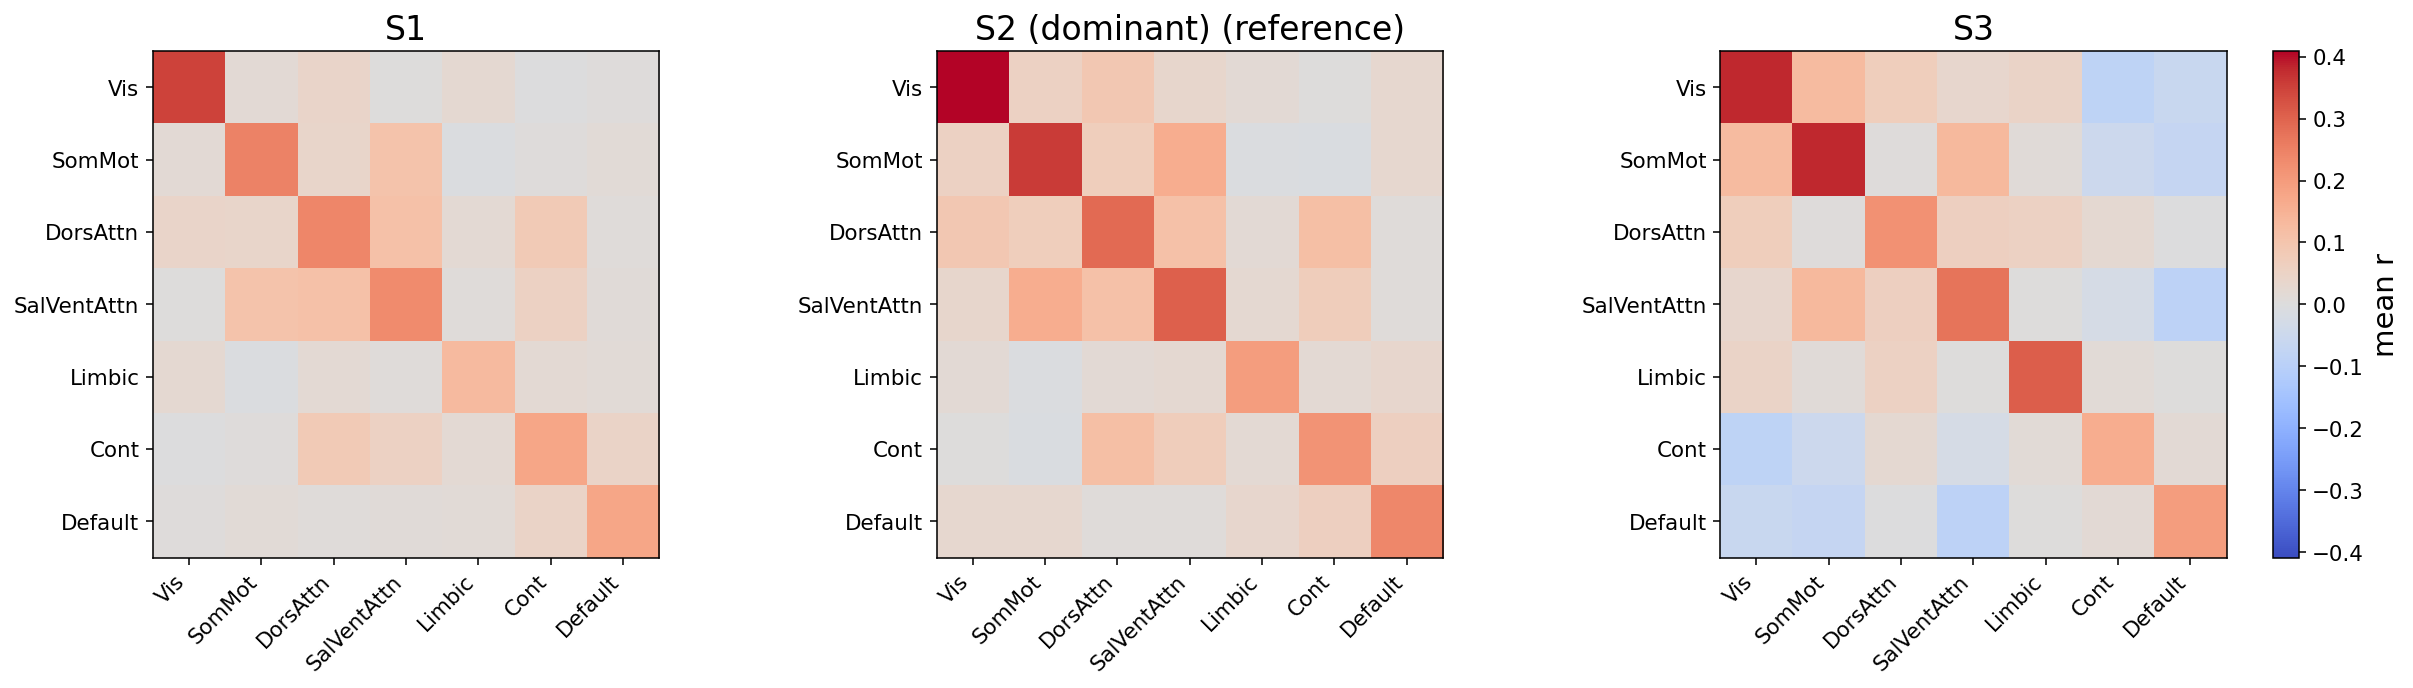

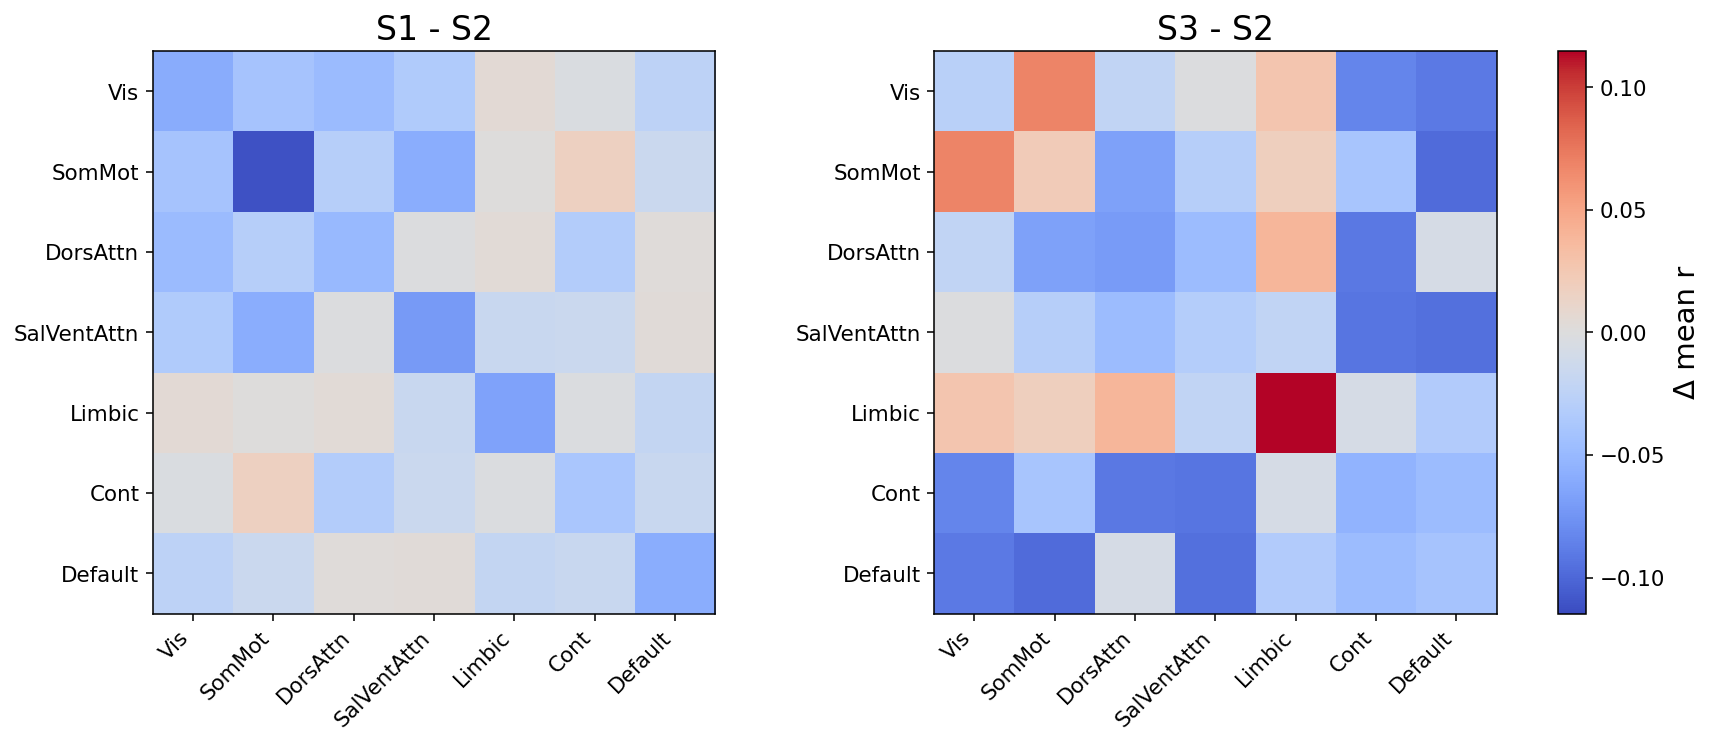

In [8]:
# =========================
# Figure 2 — network physiology heatmaps
# =========================
vmax_state = np.nanmax([np.nanmax(np.abs(b.values)) for b in block_mats])
vmax_diff = np.nanmax([np.nanmax(np.abs(block_mats[k].values - block_mats[ref_idx].values)) for k in range(K) if k != ref_idx])
fig, axes = plt.subplots(1, K, figsize=(5.6*K + 1.2, 4.8), constrained_layout=True)
for k, ax in enumerate(np.ravel(axes)):
    M = block_mats[k].values
    im = ax.imshow(M, cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0.0, vmin=-vmax_state, vmax=vmax_state))
    title = f"S{k+1}" + (" (dominant)" if k == dominant_state_idx else "") + (" (reference)" if k == ref_idx else "")
    ax.set_title(title)
    ax.set_xticks(range(len(NETWORK_ORDER)), NETWORK_ORDER, rotation=45, ha="right")
    ax.set_yticks(range(len(NETWORK_ORDER)), NETWORK_ORDER)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="mean r")
savefig(fig, "Fig2_network_blocks_states.png")

nonref = [k for k in range(K) if k != ref_idx]
fig, axes = plt.subplots(1, len(nonref), figsize=(6.3*len(nonref), 5.2), constrained_layout=True)
if len(nonref) == 1:
    axes = [axes]
for ax, k in zip(axes, nonref):
    D = block_mats[k].values - block_mats[ref_idx].values
    im = ax.imshow(D, cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0.0, vmin=-vmax_diff, vmax=vmax_diff))
    ax.set_title(f"S{k+1} - S{ref_idx+1}")
    ax.set_xticks(range(len(NETWORK_ORDER)), NETWORK_ORDER, rotation=45, ha="right")
    ax.set_yticks(range(len(NETWORK_ORDER)), NETWORK_ORDER)
fig.colorbar(im, ax=axes, fraction=0.04, pad=0.04, label="Δ mean r")
savefig(fig, "Fig2b_network_block_differences_vs_reference.png")


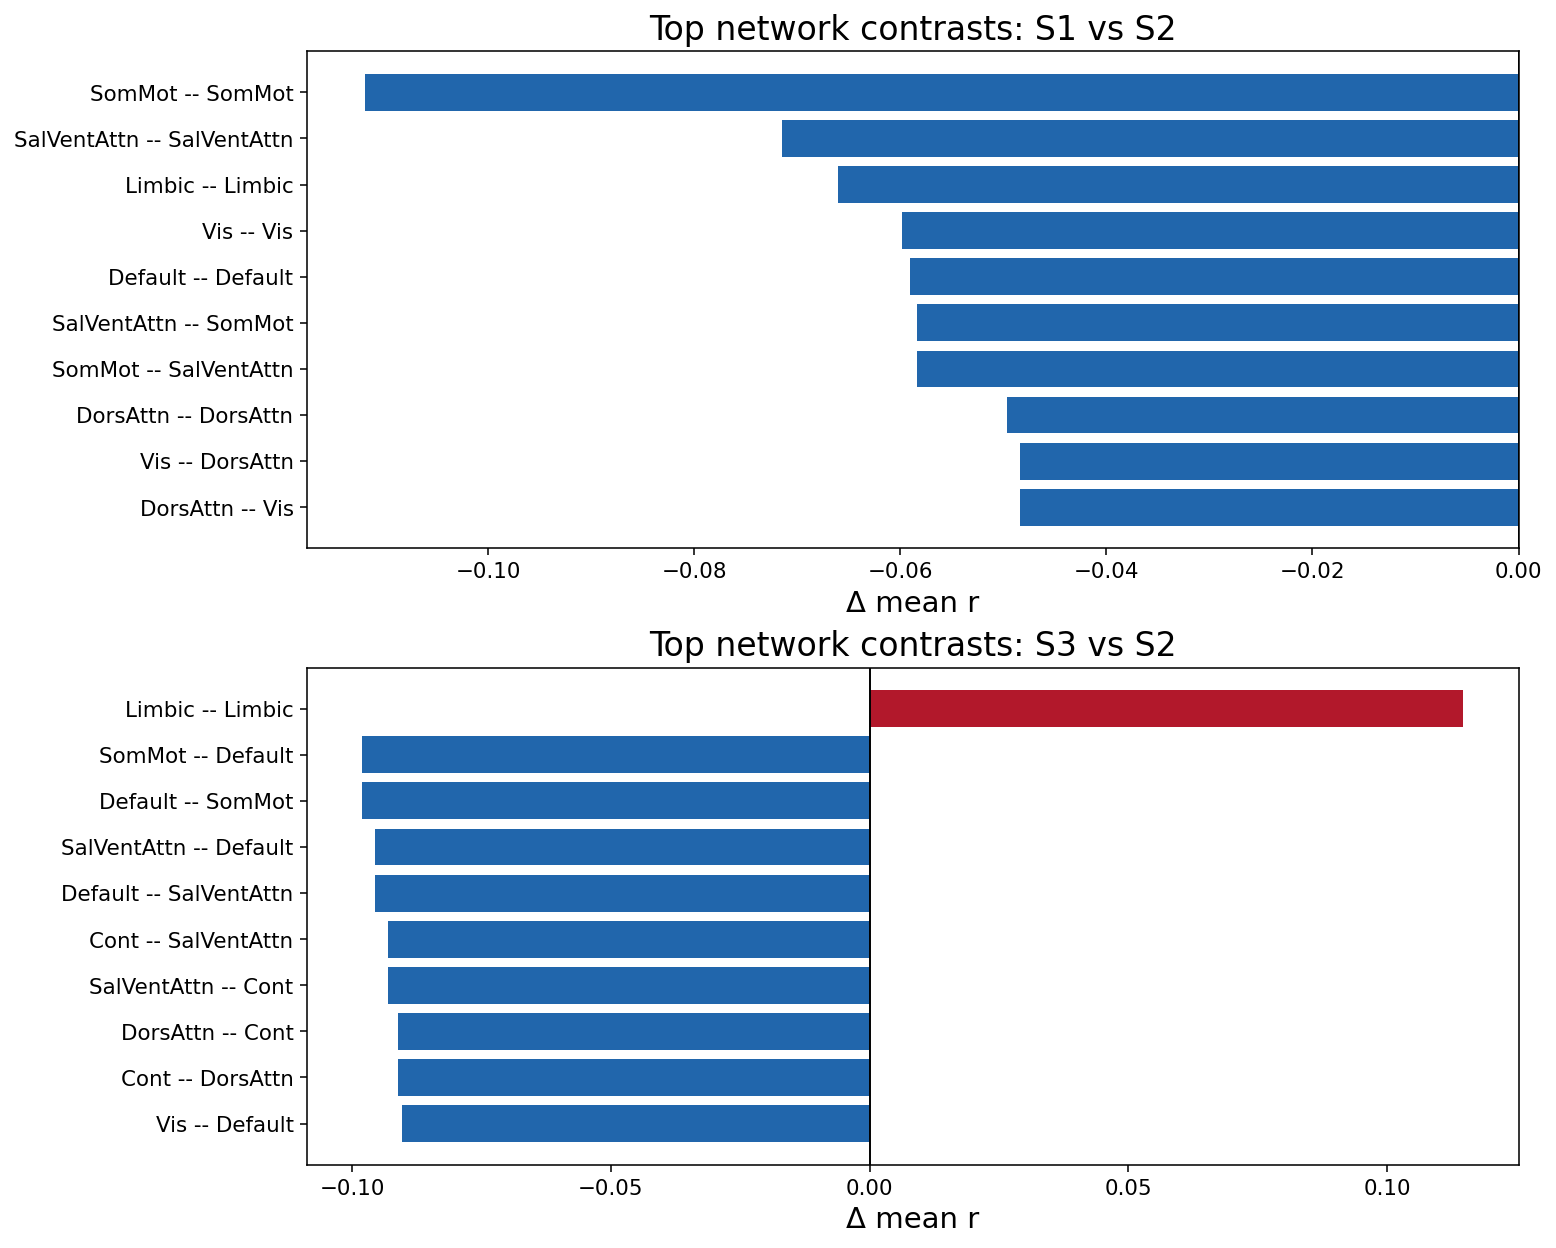

In [9]:
# =========================
# Figure 3 — ranked network contrasts
# =========================
network_contrasts = {}
for k in range(K):
    if k == ref_idx:
        continue
    D = block_mats[k] - block_mats[ref_idx]
    tmp = []
    for a in NETWORK_ORDER:
        for b in NETWORK_ORDER:
            tmp.append({
                "state": f"S{k+1}",
                "reference": f"S{ref_idx+1}",
                "pair": f"{a} -- {b}",
                "delta": float(D.loc[a, b]),
                "state_value": float(block_mats[k].loc[a, b]),
                "reference_value": float(block_mats[ref_idx].loc[a, b]),
                "abs_delta": float(abs(D.loc[a, b])),
            })
    df = pd.DataFrame(tmp).sort_values("abs_delta", ascending=False).reset_index(drop=True)
    df.to_csv(TAB_DIR / f"S{k+1}_vs_S{ref_idx+1}_top_network_contrasts.tsv", sep="	", index=False)
    network_contrasts[k] = df

fig, axes = plt.subplots(len(nonref), 1, figsize=(11, 4.4*len(nonref)), constrained_layout=True)
if len(nonref) == 1:
    axes = [axes]
for ax, k in zip(axes, nonref):
    df = network_contrasts[k].head(TOP_N_NETWORK).copy().iloc[::-1]
    colors = ["#b2182b" if d > 0 else "#2166ac" for d in df["delta"]]
    ax.barh(df["pair"], df["delta"], color=colors)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel("Δ mean r")
    ax.set_title(f"Top network contrasts: S{k+1} vs S{ref_idx+1}")
savefig(fig, "Fig3_ranked_network_contrasts.png")


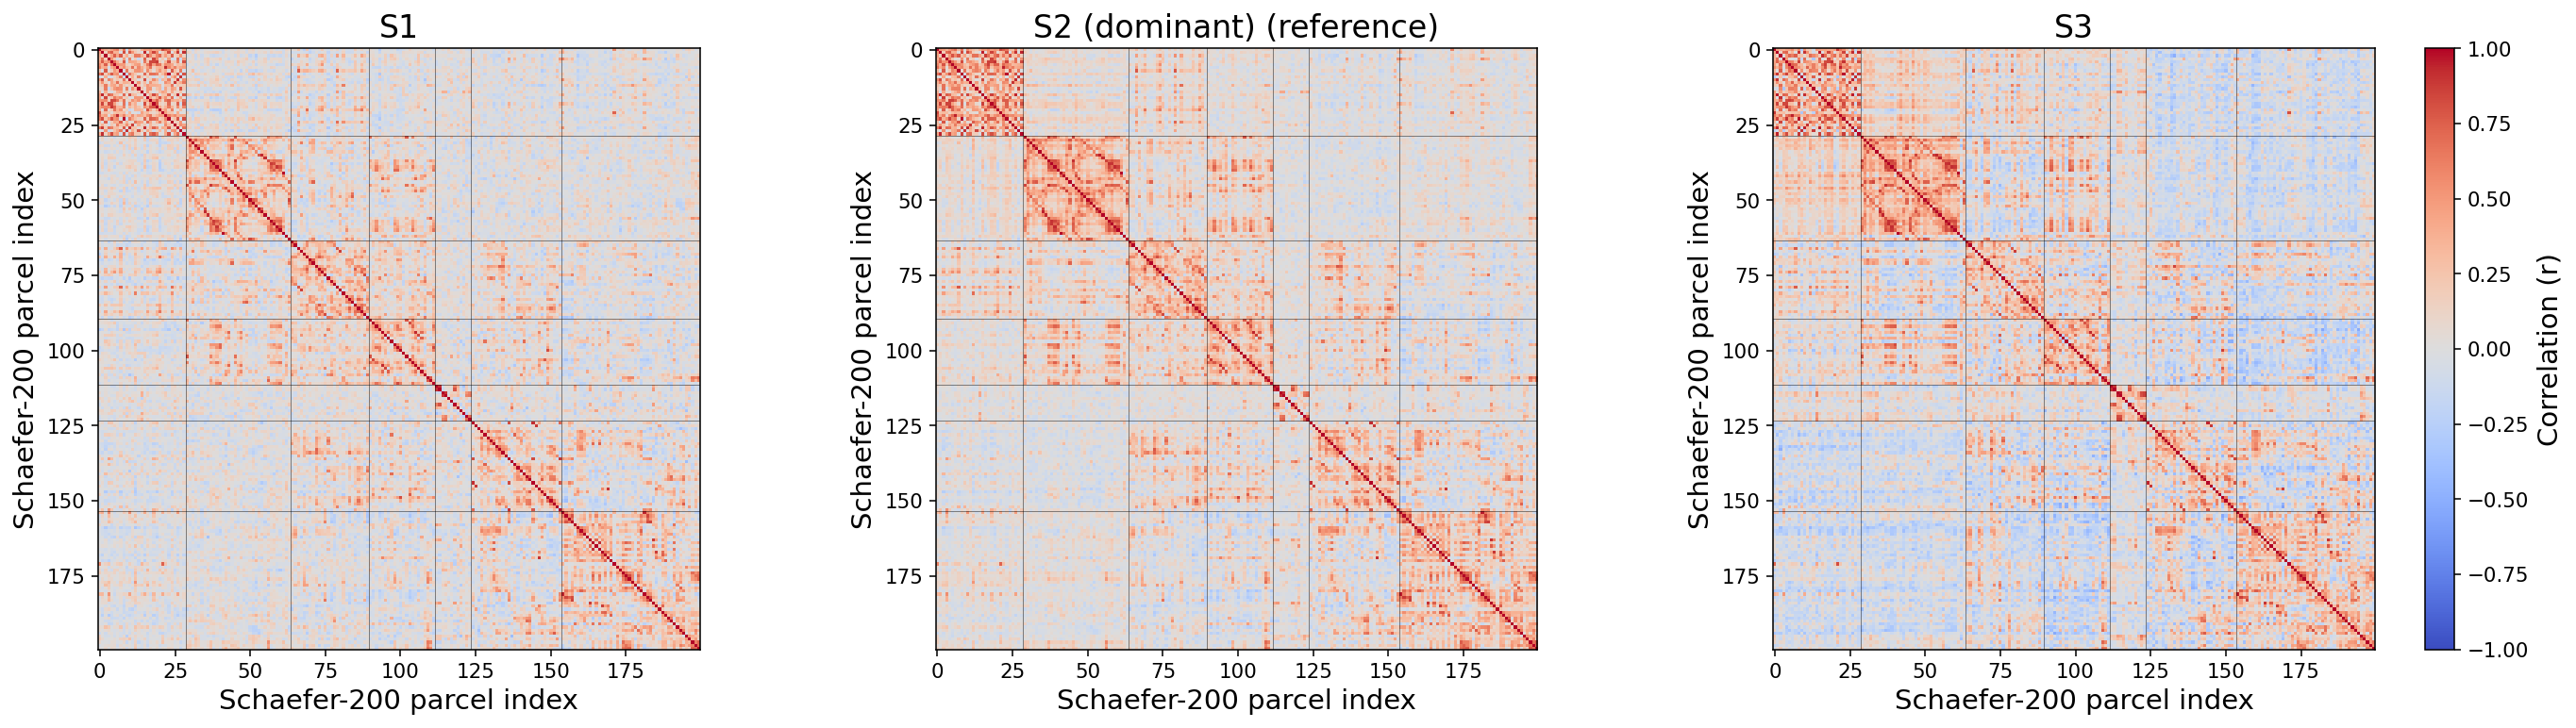

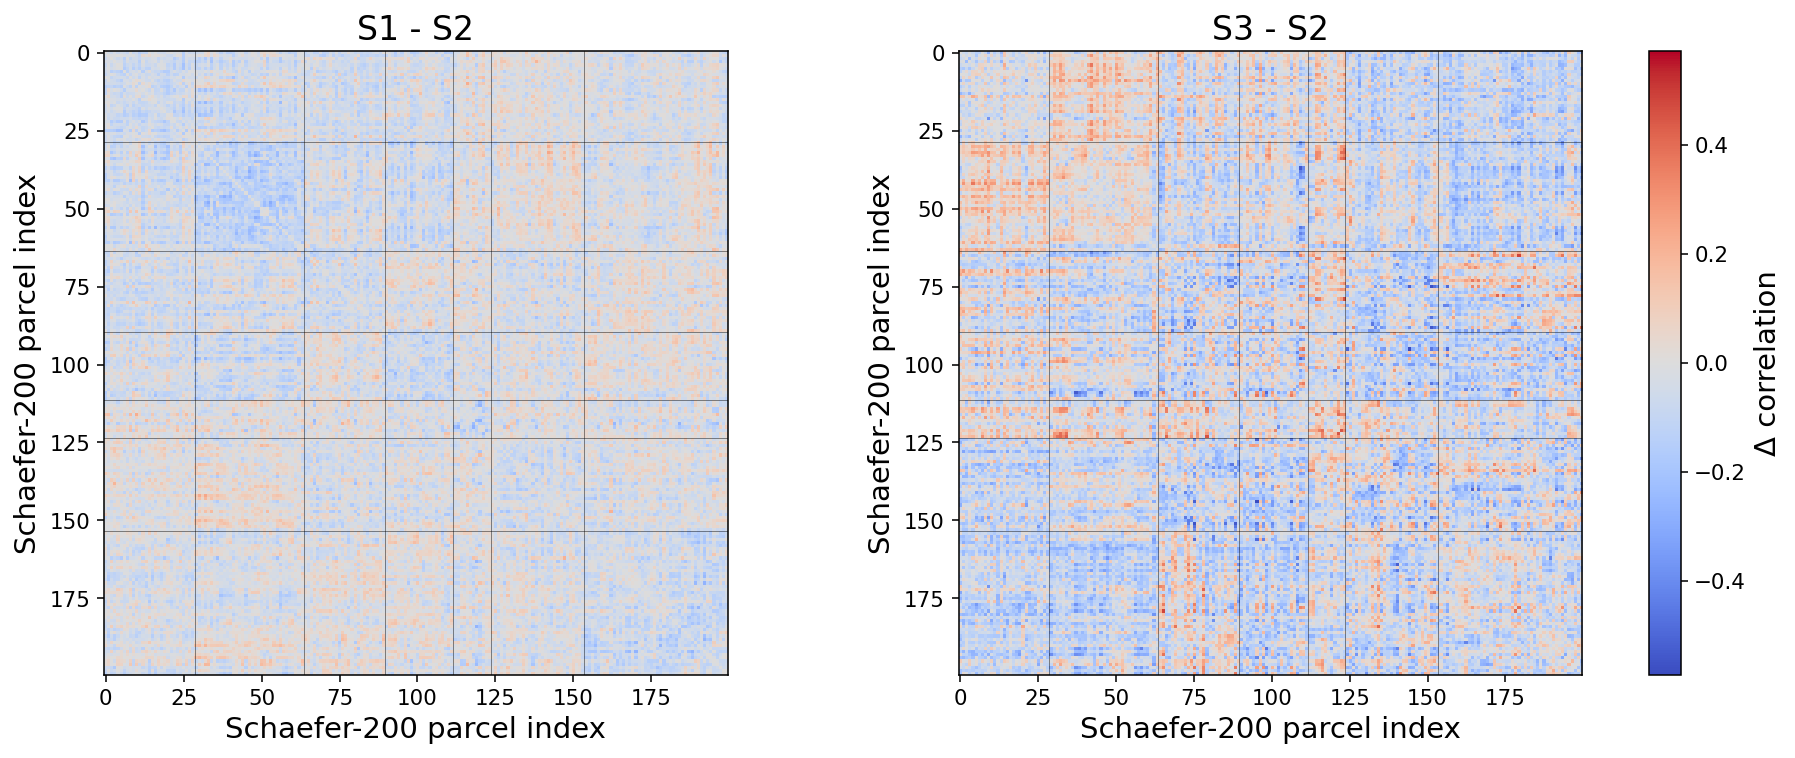

Brain-map dependencies ready: True | atlas_nii: /mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.nii.gz


/tmp/ipykernel_3248/3859637057.py:42: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_img_on_surf(img, hemispheres=["left", "right"], views=["lateral", "medial"], colorbar=True, title=title, threshold=None, cmap="coolwarm")


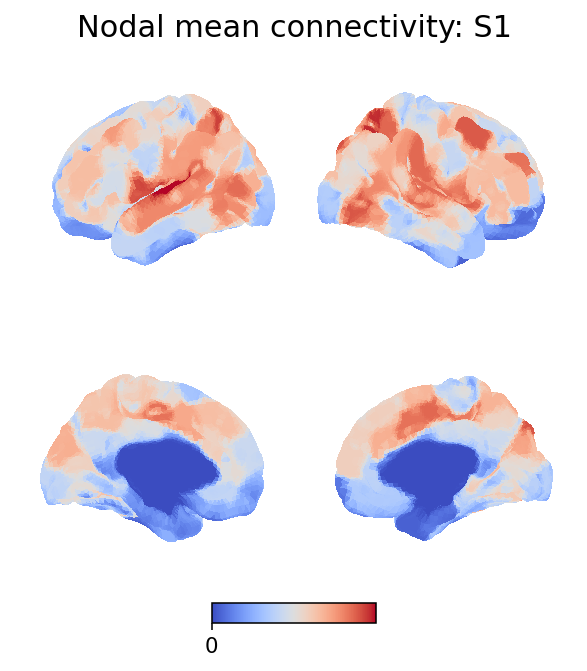

/tmp/ipykernel_3248/3859637057.py:42: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_img_on_surf(img, hemispheres=["left", "right"], views=["lateral", "medial"], colorbar=True, title=title, threshold=None, cmap="coolwarm")


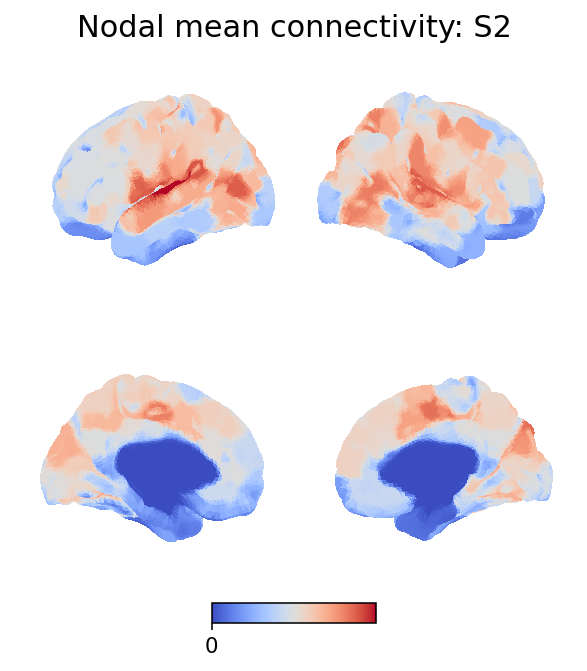

/tmp/ipykernel_3248/3859637057.py:42: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_img_on_surf(img, hemispheres=["left", "right"], views=["lateral", "medial"], colorbar=True, title=title, threshold=None, cmap="coolwarm")


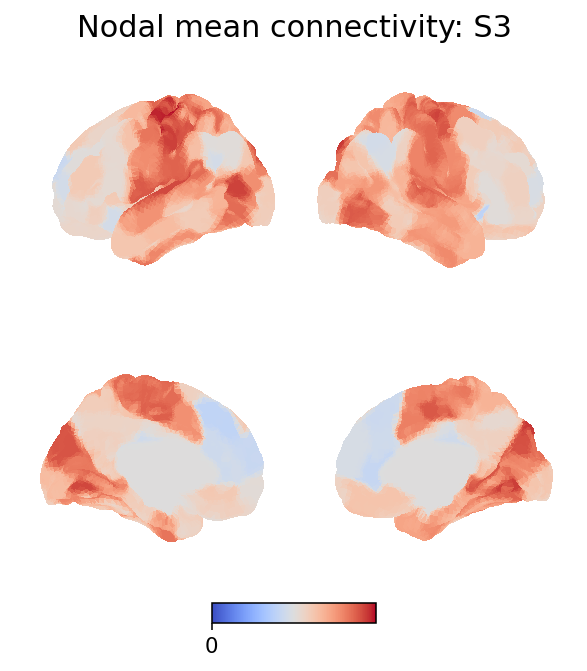

/tmp/ipykernel_3248/3859637057.py:42: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_img_on_surf(img, hemispheres=["left", "right"], views=["lateral", "medial"], colorbar=True, title=title, threshold=None, cmap="coolwarm")


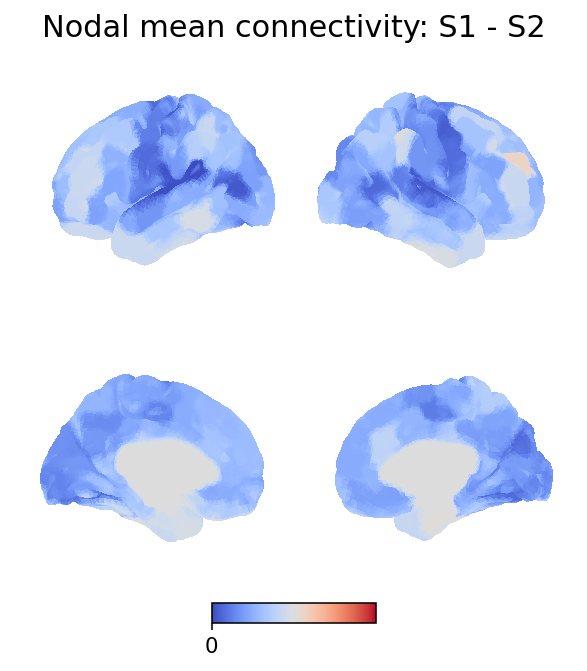

/tmp/ipykernel_3248/3859637057.py:42: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_img_on_surf(img, hemispheres=["left", "right"], views=["lateral", "medial"], colorbar=True, title=title, threshold=None, cmap="coolwarm")


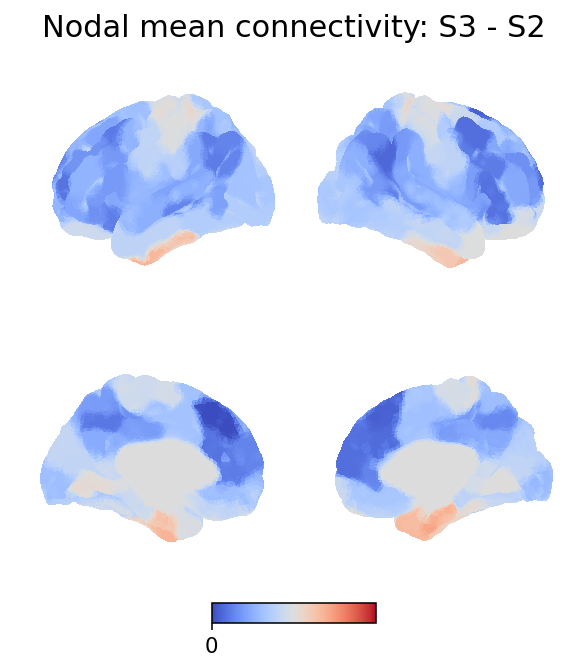

In [10]:
# =========================
# Figure 4 — parcel heatmaps and brain maps
# =========================
vmax_parcel = np.nanmax(np.abs(parcel_mats_ord))
vmax_parcel_diff = np.nanmax(np.abs(parcel_mats_ord - parcel_mats_ord[ref_idx]))
sizes, bounds = network_boundaries(ordered_labels_df, NETWORK_ORDER)

fig, axes = plt.subplots(1, K, figsize=(6.3*K + 1.5, 5.4), constrained_layout=True)
for k, ax in enumerate(np.ravel(axes)):
    M = parcel_mats_ord[k]
    im = ax.imshow(M, cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0.0, vmin=-vmax_parcel, vmax=vmax_parcel))
    ax.set_title(f"S{k+1}" + (" (dominant)" if k == dominant_state_idx else "") + (" (reference)" if k == ref_idx else ""))
    ax.set_xlabel("Schaefer-200 parcel index")
    ax.set_ylabel("Schaefer-200 parcel index")
    for b in bounds[:-1]:
        ax.axhline(b-0.5, color="k", lw=0.5, alpha=0.45)
        ax.axvline(b-0.5, color="k", lw=0.5, alpha=0.45)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Correlation (r)")
savefig(fig, "Fig4_parcel_heatmaps_states.png")

fig, axes = plt.subplots(1, len(nonref), figsize=(6.4*len(nonref) + 0.8, 5.3), constrained_layout=True)
if len(nonref) == 1:
    axes = [axes]
for ax, k in zip(axes, nonref):
    D = parcel_mats_ord[k] - parcel_mats_ord[ref_idx]
    im = ax.imshow(D, cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0.0, vmin=-vmax_parcel_diff, vmax=vmax_parcel_diff))
    ax.set_title(f"S{k+1} - S{ref_idx+1}")
    ax.set_xlabel("Schaefer-200 parcel index")
    ax.set_ylabel("Schaefer-200 parcel index")
    for b in bounds[:-1]:
        ax.axhline(b-0.5, color="k", lw=0.5, alpha=0.45)
        ax.axvline(b-0.5, color="k", lw=0.5, alpha=0.45)
fig.colorbar(im, ax=axes, fraction=0.04, pad=0.04, label="Δ correlation")
savefig(fig, "Fig4b_parcel_heatmap_differences_vs_reference.png")

parcel_maps_available = (nib is not None) and (plotting is not None) and (optional["atlas_nii"] is not None)
print("Brain-map dependencies ready:", parcel_maps_available, "| atlas_nii:", optional["atlas_nii"])
if parcel_maps_available:
    def draw_brain_map(parcel_vals, title, out_name):
        img = parcel_values_to_img(parcel_vals, optional["atlas_nii"])
        try:
            plotting.plot_img_on_surf(img, hemispheres=["left", "right"], views=["lateral", "medial"], colorbar=True, title=title, threshold=None, cmap="coolwarm")
            plt.savefig(FIG_DIR / out_name, bbox_inches="tight", dpi=300)
            plt.show()
        except Exception as e:
            print(f"Surface plotting failed for {title}: {e}")
            display = plotting.plot_stat_map(img, display_mode="ortho", colorbar=True, title=title, cmap="coolwarm", symmetric_cbar=True)
            display.savefig(FIG_DIR / out_name, dpi=300)
            plt.show()
    for k in range(K):
        draw_brain_map(nodal_mean[k], f"Nodal mean connectivity: S{k+1}", f"Fig4c_brainmap_nodal_mean_S{k+1}.png")
    for k in nonref:
        draw_brain_map(nodal_mean[k] - nodal_mean[ref_idx], f"Nodal mean connectivity: S{k+1} - S{ref_idx+1}", f"Fig4d_brainmap_nodal_mean_S{k+1}_minus_S{ref_idx+1}.png")
else:
    print("Skipping brain-map images because nibabel/nilearn/atlas NIfTI are unavailable.")


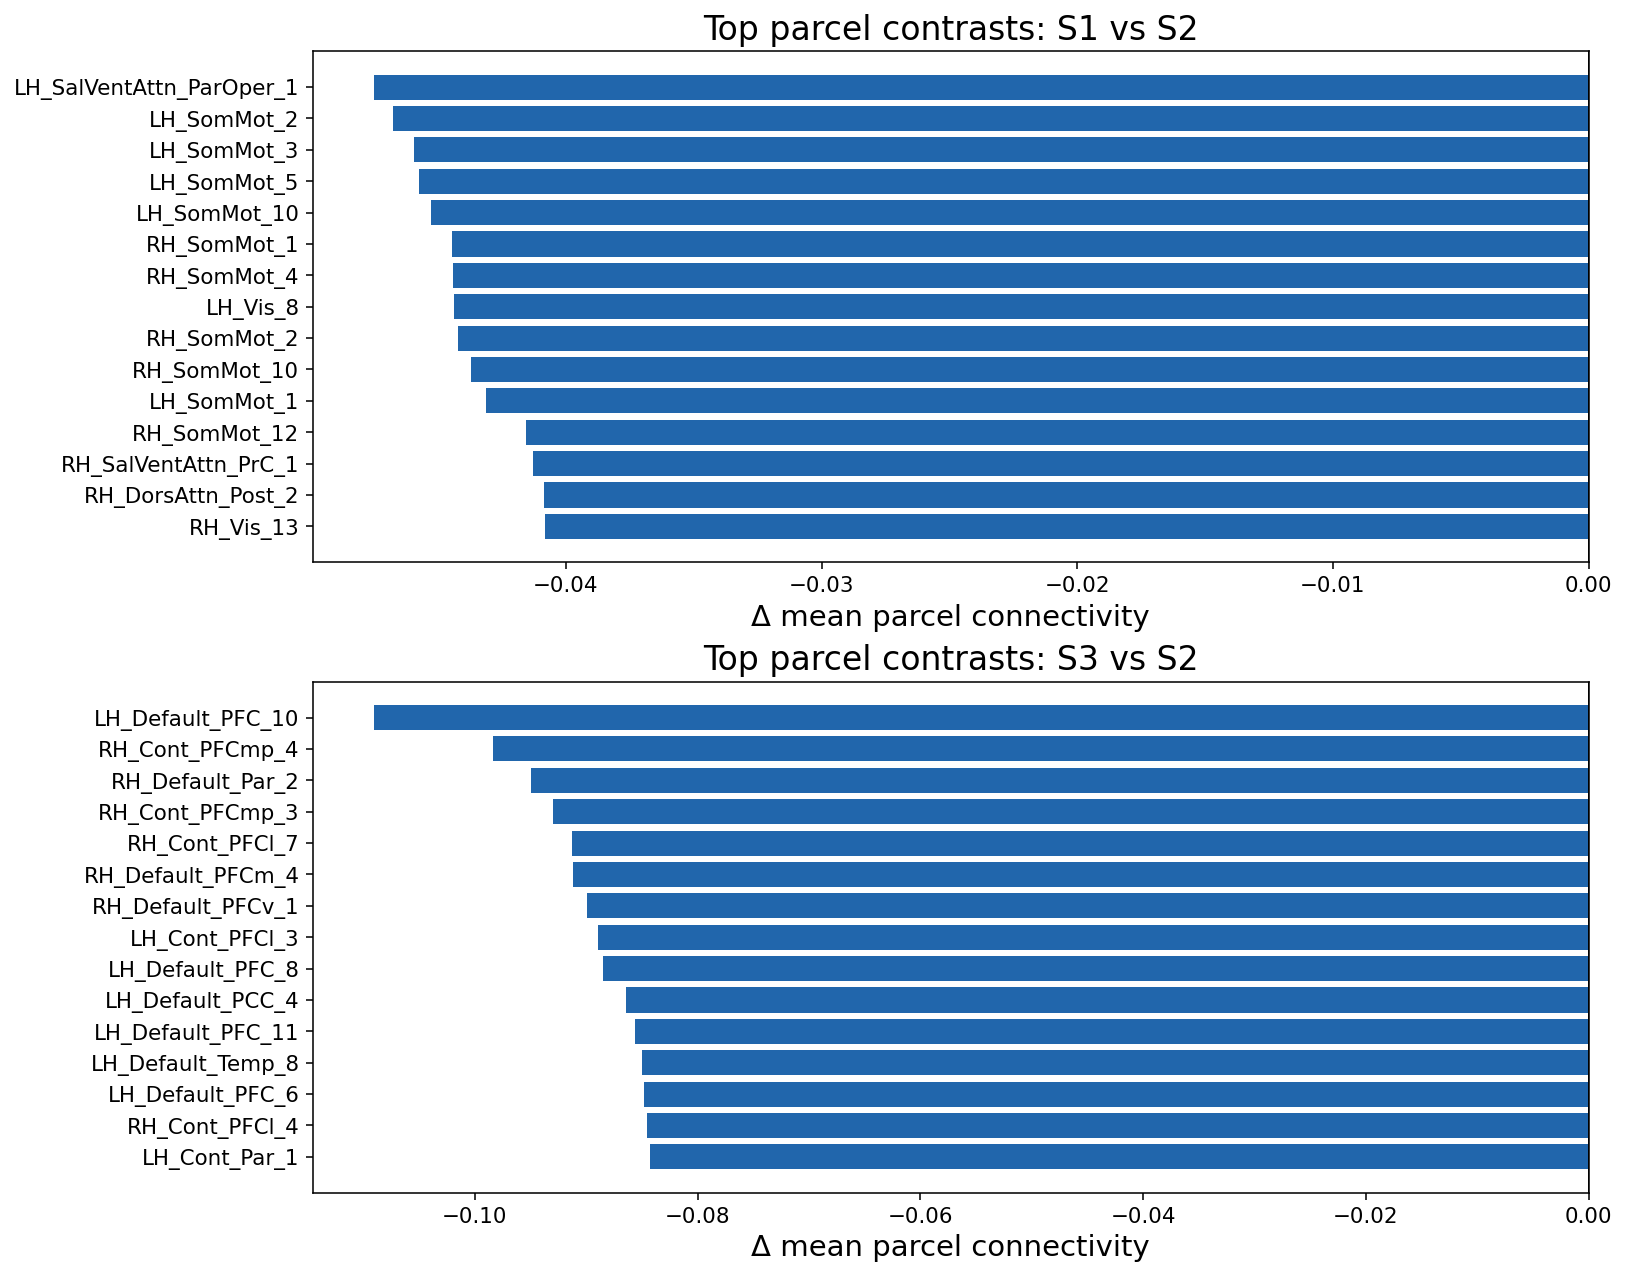

,network,count,state
0,SomMot,10,S1
1,SalVentAttn,2,S1
2,Vis,2,S1
3,DorsAttn,1,S1
4,Default,9,S3
5,Cont,6,S3


In [11]:
# =========================
# Figure 5 — ranked parcel contrasts and nodal summaries
# =========================
parcel_contrasts = {}
for k in range(K):
    if k == ref_idx:
        continue
    delta = nodal_mean[k] - nodal_mean[ref_idx]
    df = labels_df_raw.copy()
    df["delta_mean_r"] = delta
    df["abs_delta_mean_r"] = np.abs(delta)
    df = df.sort_values("abs_delta_mean_r", ascending=False).reset_index(drop=True)
    out = df[["index", "label", "label_short", "network", "hemi", "delta_mean_r", "abs_delta_mean_r"]]
    out.to_csv(TAB_DIR / f"S{k+1}_vs_S{ref_idx+1}_top_parcel_contrasts.tsv", sep="	", index=False)
    parcel_contrasts[k] = out
for k in range(K):
    df = labels_df_raw.copy()
    df["mean_r"] = nodal_mean[k]
    df["abs_mean_r"] = np.abs(nodal_mean[k])
    df = df.sort_values("abs_mean_r", ascending=False).reset_index(drop=True)
    df.to_csv(TAB_DIR / f"S{k+1}_nodal_mean_connectivity.tsv", sep="	", index=False)

fig, axes = plt.subplots(len(nonref), 1, figsize=(11.5, 4.5*len(nonref)), constrained_layout=True)
if len(nonref) == 1:
    axes = [axes]
for ax, k in zip(axes, nonref):
    df = parcel_contrasts[k].head(TOP_N_PARCEL).copy().iloc[::-1]
    colors = ["#b2182b" if d > 0 else "#2166ac" for d in df["delta_mean_r"]]
    ax.barh(df["label_short"], df["delta_mean_r"], color=colors)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel("Δ mean parcel connectivity")
    ax.set_title(f"Top parcel contrasts: S{k+1} vs S{ref_idx+1}")
savefig(fig, "Fig5_ranked_parcel_contrasts.png")

top_parcel_network_mix = []
for k in nonref:
    mix = parcel_contrasts[k].head(TOP_N_PARCEL)["network"].value_counts().rename_axis("network").reset_index(name="count")
    mix["state"] = f"S{k+1}"
    top_parcel_network_mix.append(mix)
top_parcel_network_mix = pd.concat(top_parcel_network_mix, ignore_index=True)
display(top_parcel_network_mix)
top_parcel_network_mix.to_csv(TAB_DIR / "top_parcel_network_mix.tsv", sep="	", index=False)


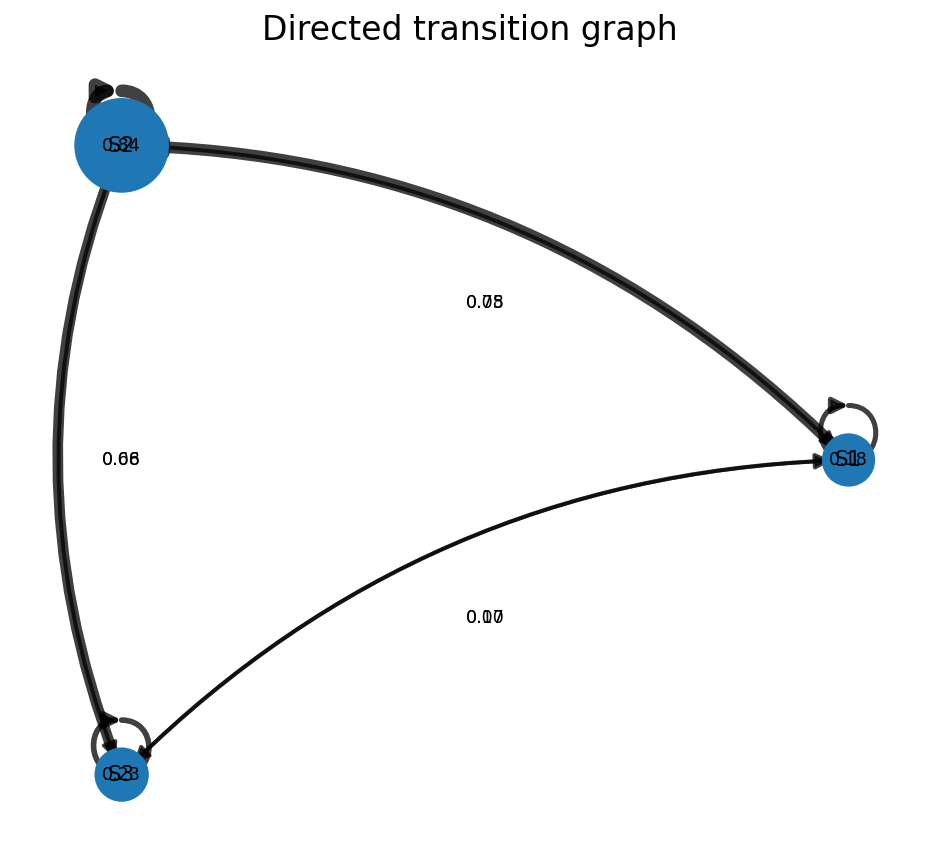

plotly is not installed; skipping Sankey.


In [12]:
# =========================
# Optional Figure 6 — transition graph and Sankey
# =========================
if nx is None:
    print("networkx is not installed; skipping directed transition graph.")
else:
    G = nx.DiGraph()
    states = [f"S{i+1}" for i in range(K)]
    for s in states:
        G.add_node(s)
    for i in range(K):
        for j in range(K):
            G.add_edge(states[i], states[j], weight=float(A[i, j]))
    pos = {}
    for i, s in enumerate(states):
        theta = 2 * np.pi * i / K
        pos[s] = (np.cos(theta), np.sin(theta))
    fig, ax = plt.subplots(figsize=(6.6, 6.0), constrained_layout=True)
    nx.draw_networkx_nodes(G, pos, node_size=[2200 * final_fo[i] + 500 for i in range(K)], ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=11, ax=ax)
    for i in range(K):
        for j in range(K):
            rad = 0.20 if i != j else 0.35
            width = 1.5 + 6.0 * A[i, j]
            nx.draw_networkx_edges(G, pos, edgelist=[(states[i], states[j])], width=width, alpha=0.75, arrows=True, arrowstyle="-|>", arrowsize=16, connectionstyle=f"arc3,rad={rad if i<j else -rad}", ax=ax)
            sx, sy = pos[states[i]]
            tx, ty = pos[states[j]]
            ax.text((sx+tx)/2, (sy+ty)/2, f"{A[i,j]:.2f}", fontsize=9, ha="center", va="center")
    ax.set_title("Directed transition graph")
    ax.axis("off")
    savefig(fig, "Fig6_transition_graph.png")

if go is None:
    print("plotly is not installed; skipping Sankey.")
else:
    labels = [f"S{i+1}" for i in range(K)] + [f"S{i+1}" for i in range(K)]
    source, target, value = [], [], []
    for i in range(K):
        for j in range(K):
            source.append(i)
            target.append(K + j)
            value.append(float(A[i, j]))
    fig = go.Figure(data=[go.Sankey(node=dict(label=labels, pad=20, thickness=18), link=dict(source=source, target=target, value=value))])
    fig.update_layout(title_text="State-to-state flow (Sankey from A)", font_size=11)
    html_path = FIG_DIR / "Fig6b_transition_sankey.html"
    fig.write_html(str(html_path))
    print("Saved Sankey HTML to:", html_path)
    fig.show()


In [13]:
# =========================
# State-by-state glossary and caption text
# =========================
def top_network_sentence(k, n=4):
    df = network_contrasts[k].copy()
    pos = df[df["delta"] > 0].head(n)["pair"].tolist()
    neg = df[df["delta"] < 0].head(n)["pair"].tolist()
    return pos, neg

def top_parcel_sentence(k, n=6):
    df = parcel_contrasts[k].copy()
    neg = df[df["delta_mean_r"] < 0].head(n)["label_short"].tolist()
    pos = df[df["delta_mean_r"] > 0].head(n)["label_short"].tolist()
    return pos, neg

glossary_rows = []
for k in range(K):
    s = f"S{k+1}"
    fo = final_fo[k]
    dwell_tr = 1.0 / (1.0 - A[k, k])
    dwell_sec = TR_SEC / (1.0 - A[k, k])
    top_blocks = [state_summary.loc[k, f"top_block_{i}"] for i in range(1, 6)]
    top_block_vals = [state_summary.loc[k, f"top_block_{i}_value"] for i in range(1, 6)]
    if k == ref_idx:
        text = (
            f"{s} is the dominant/reference state (FO = {fo:.4f}; expected dwell ≈ {dwell_tr:.2f} TR, {dwell_sec:.2f} s) "
            f"and shows the strongest broad within-network organization, with leading blocks in "
            + ", ".join([f"{p} ({v:.3f})" for p, v in zip(top_blocks[:5], top_block_vals[:5])]) + ". "
            + "At parcel level, its nodal mean connectivity profile can be used as the backbone map for the other state differences."
        )
    else:
        pos_pairs, neg_pairs = top_network_sentence(k, n=4)
        pos_parcels, neg_parcels = top_parcel_sentence(k, n=6)
        style = "an attenuated variant of the dominant state" if np.mean(nodal_mean[k] - nodal_mean[ref_idx]) < 0 else "a selectively reconfigured alternative state"
        text = (
            f"{s} is a non-dominant state (FO = {fo:.4f}; expected dwell ≈ {dwell_tr:.2f} TR, {dwell_sec:.2f} s) that appears as {style}. "
            f"Relative to S{ref_idx+1}, the strongest positive network shifts are "
            + (", ".join(pos_pairs) if len(pos_pairs) else "minimal")
            + ", whereas the strongest negative shifts are "
            + (", ".join(neg_pairs) if len(neg_pairs) else "minimal")
            + ". Parcel-level positive drivers include "
            + (", ".join(pos_parcels) if len(pos_parcels) else "few large positive parcel shifts")
            + ", while the strongest negative parcel drivers include "
            + (", ".join(neg_parcels) if len(neg_parcels) else "few large negative parcel shifts")
            + "."
        )
    glossary_rows.append({"state": s, "glossary_text": text})

glossary_df = pd.DataFrame(glossary_rows)
display(glossary_df)
glossary_df.to_csv(TAB_DIR / "state_biological_glossary.tsv", sep="	", index=False)
(Path(TAB_DIR / "state_biological_glossary.txt")).write_text("\n\n".join([f"{r.state}: {r.glossary_text}" for r in glossary_df.itertuples(index=False)]), encoding="utf-8")
print("Saved tables:")
for p in sorted(TAB_DIR.glob("*")):
    print(" -", p.name)


,state,glossary_text
0,S1,S1 is a non-dominant state (FO = 0.0898; expec...
1,S2,S2 is the dominant/reference state (FO = 0.807...
2,S3,S3 is a non-dominant state (FO = 0.1026; expec...


Saved tables:
 - S1_nodal_mean_connectivity.tsv
 - S1_vs_S2_top_network_contrasts.tsv
 - S1_vs_S2_top_parcel_contrasts.tsv
 - S2_nodal_mean_connectivity.tsv
 - S3_nodal_mean_connectivity.tsv
 - S3_vs_S2_top_network_contrasts.tsv
 - S3_vs_S2_top_parcel_contrasts.tsv
 - run_state_series_summary.tsv
 - state_biological_glossary.tsv
 - state_biological_glossary.txt
 - state_summary_table.tsv
 - top_parcel_network_mix.tsv


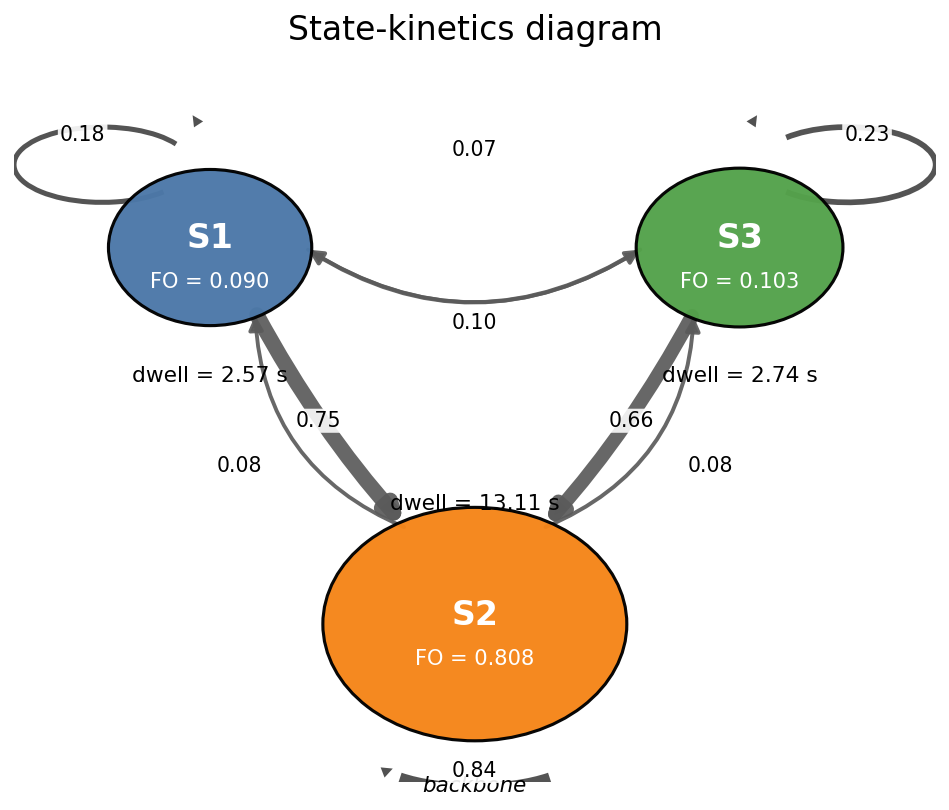

Saved -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures/figures/Fig_state_kinetics_diagram_compact_sym.png


In [15]:
# ============================================
# Add-on figure: state-kinetics diagram
# Requires:
#   A            : (K x K) transition matrix
#   final_fo     : length-K FO vector
#   state_summary: dataframe with expected_dwell_sec (optional but preferred)
#   TR_SEC       : TR in seconds
# Optional:
#   FIG_DIR      : output directory
# ============================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Arc

def _get_dwell_sec(A, state_summary=None, tr_sec=2.1):
    A = np.asarray(A, dtype=float)
    dwell_sec = tr_sec / np.clip(1.0 - np.diag(A), 1e-12, None)

    if state_summary is not None and "expected_dwell_sec" in state_summary.columns:
        ss = state_summary.copy()
        if "state" in ss.columns:
            ss = ss.sort_values("state")
        dwell_sec = ss["expected_dwell_sec"].to_numpy(dtype=float)

    return dwell_sec


def plot_state_kinetics_diagram_compact_sym(
    A,
    fo,
    state_names=None,
    dwell_sec=None,
    title="State-kinetics diagram",
    baseline_label="backbone",
    save_path=None,
    dpi=300
):
    """
    Compact 3-state kinetics diagram with:
    - S1 top-left, S3 top-right, S2 bottom-center
    - fully separated symmetric reciprocal arcs
    - self-loops
    - node area ~ FO
    - edge/loop thickness ~ transition probability
    """

    A = np.asarray(A, dtype=float)
    fo = np.asarray(fo, dtype=float)

    if A.shape != (3, 3):
        raise ValueError("This helper expects a 3x3 transition matrix.")
    if fo.shape[0] != 3:
        raise ValueError("FO vector must have length 3.")

    if state_names is None:
        state_names = ["S1", "S2", "S3"]

    if dwell_sec is None:
        dwell_sec = 2.1 / np.clip(1.0 - np.diag(A), 1e-12, None)

    # ----------------------------
    # Layout
    # ----------------------------
    # State order:
    # 0 = S1, 1 = S2, 2 = S3
    pos = {
        0: np.array([0.23, 0.73]),   # S1
        1: np.array([0.50, 0.23]),   # S2
        2: np.array([0.77, 0.73]),   # S3
    }

    # Radius scaling so area roughly tracks FO
    fo_safe = np.clip(fo, 1e-12, None)
    r_min, r_max = 0.078, 0.155
    fo_norm = np.sqrt(fo_safe / fo_safe.max())
    radii = r_min + (r_max - r_min) * fo_norm

    # Transition width scaling
    offdiag = A.copy()
    np.fill_diagonal(offdiag, 0.0)
    max_offdiag = max(float(offdiag.max()), 1e-6)

    def edge_width(p):
        return 1.3 + 6.6 * (p / max_offdiag)

    def loop_width(p):
        return 1.4 + 6.5 * p

    node_facecolors = ["#4C78A8", "#F58518", "#54A24B"]
    node_edgecolor = "black"
    arrow_color = "#5A5A5A"
    loop_color = "#4D4D4D"

    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    ax.set_xlim(0.03, 0.97)
    ax.set_ylim(0.02, 0.98)
    ax.axis("off")
    ax.set_title(title, fontsize=17, pad=10)

    # ----------------------------
    # Helper for directed arrows
    # ----------------------------
    def add_arrow(i, j, rad, label_xy):
        p = float(A[i, j])
        if p <= 0:
            return

        start = pos[i]
        end = pos[j]
        vec = end - start
        dist = np.linalg.norm(vec)
        u = vec / dist

        # Start/end on node boundaries
        p0 = start + u * radii[i] * 0.93
        p1 = end - u * radii[j] * 0.93

        arrow = FancyArrowPatch(
            p0, p1,
            connectionstyle=f"arc3,rad={rad}",
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=edge_width(p),
            color=arrow_color,
            alpha=0.92,
            zorder=2
        )
        ax.add_patch(arrow)

        ax.text(
            label_xy[0], label_xy[1], f"{p:.2f}",
            ha="center", va="center",
            fontsize=10.5,
            bbox=dict(
                boxstyle="round,pad=0.10",
                fc="white",
                ec="none",
                alpha=0.88
            ),
            zorder=6
        )

    # ----------------------------
    # Reciprocal arrows: fully separated and symmetric
    # ----------------------------
    # Left pair: S1 <-> S2
    add_arrow(0, 1,  0.06, (0.34, 0.50))  # S1 -> S2
    add_arrow(1, 0, -0.32, (0.26, 0.44))  # S2 -> S1

    # Right pair: S2 <-> S3
    add_arrow(2, 1, -0.06, (0.66, 0.50))  # S3 -> S2
    add_arrow(1, 2,  0.32, (0.74, 0.44))  # S2 -> S3

    # Top pair: S1 <-> S3
    add_arrow(0, 2,  0.32, (0.50, 0.86))  # S1 -> S3
    add_arrow(2, 0, -0.32, (0.50, 0.63))  # S3 -> S1

    # ----------------------------
    # Self-loops
    # ----------------------------
    loop_specs = {
        0: dict(center=(0.12, 0.84), w=0.18, h=0.10, t1=20,  t2=330, label=(0.10, 0.88)),
        1: dict(center=(0.50, 0.06), w=0.22, h=0.10, t1=205, t2=-25, label=(0.50, 0.035)),
        2: dict(center=(0.88, 0.84), w=0.18, h=0.10, t1=210, t2=150, label=(0.90, 0.88)),
    }

    for i in range(3):
        p = float(A[i, i])
        spec = loop_specs[i]

        arc = Arc(
            spec["center"],
            width=spec["w"],
            height=spec["h"],
            theta1=spec["t1"],
            theta2=spec["t2"],
            linewidth=loop_width(p),
            color=loop_color,
            alpha=0.96,
            zorder=1
        )
        ax.add_patch(arc)

        # arrowheads for loops
        if i == 0:
            head_start, head_end = (0.22, 0.89), (0.21, 0.91)
        elif i == 1:
            head_start, head_end = (0.40, 0.03), (0.42, 0.04)
        else:
            head_start, head_end = (0.78, 0.89), (0.79, 0.91)

        head = FancyArrowPatch(
            head_start, head_end,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=0,
            color=loop_color,
            alpha=0.98,
            zorder=3
        )
        ax.add_patch(head)

        lx, ly = spec["label"]
        ax.text(
            lx, ly, f"{p:.2f}",
            ha="center", va="center",
            fontsize=10.5,
            bbox=dict(
                boxstyle="round,pad=0.10",
                fc="white",
                ec="none",
                alpha=0.90
            ),
            zorder=6
        )

    # ----------------------------
    # Nodes
    # ----------------------------
    for i in range(3):
        circle = Circle(
            pos[i],
            radius=radii[i],
            facecolor=node_facecolors[i],
            edgecolor=node_edgecolor,
            linewidth=1.6,
            alpha=0.97,
            zorder=10
        )
        ax.add_patch(circle)

        ax.text(
            pos[i][0], pos[i][1] + 0.012,
            state_names[i],
            ha="center", va="center",
            fontsize=17,
            fontweight="bold",
            color="white",
            zorder=11
        )

        ax.text(
            pos[i][0], pos[i][1] - 0.046,
            f"FO = {fo[i]:.3f}",
            ha="center", va="center",
            fontsize=10.8,
            color="white",
            zorder=11
        )

    # ----------------------------
    # Dwell text
    # ----------------------------
    dwell_pos = {
        0: (0.23, 0.56),
        1: (0.50, 0.39),
        2: (0.77, 0.56),
    }

    for i in range(3):
        dx, dy = dwell_pos[i]
        ax.text(
            dx, dy,
            f"dwell = {dwell_sec[i]:.2f} s",
            ha="center",
            va="center",
            fontsize=11.2,
            zorder=11
        )

    # ----------------------------
    # Baseline/backbone label
    # ----------------------------
    ax.text(
        0.50,
        0.015,
        baseline_label,
        ha="center",
        va="center",
        fontsize=11,
        style="italic"
    )

    plt.tight_layout(pad=0.6)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    return fig, ax

state_names = ["S1", "S2", "S3"]
dwell_sec = _get_dwell_sec(A, state_summary=state_summary, tr_sec=TR_SEC)

save_path = None
if "FIG_DIR" in globals():
    save_path = Path(FIG_DIR) / "Fig_state_kinetics_diagram_compact_sym.png"

fig, ax = plot_state_kinetics_diagram_compact_sym(
    A=A,
    fo=final_fo,
    state_names=state_names,
    dwell_sec=dwell_sec,
    title="State-kinetics diagram",
    baseline_label="backbone",   # or "dominant"
    save_path=save_path,
    dpi=300
)

if save_path is not None:
    print(f"Saved -> {save_path}")